# Clasificación de Supervivencia en el Titanic — 8 modelos de ML (Semana 2)

**Maestría en Inteligencia Artificial Aplicada — UIDE**
**Asignatura:** Aprendizaje Automático Estadístico — MIA-B
**Docente:** PhD. Iván García Santillán
**Semana 2 — Componente práctico (Práctica Grupal — Grupo 2)**

**Integrantes (Grupo 2):**
- Gualli Ramírez, Jonathan Fabricio
- Quizamánchuro Fuel, Jorge Armando
- Salazar Gamboa, Raúl Marcelo

---

## Resumen del trabajo

Este notebook desarrolla un flujo completo de **clasificación binaria supervisada** sobre el dataset
**Breast Cancer Wisconsin Diagnostic (WBCD)** del repositorio UCI, con el objetivo de distinguir
tumores **malignos** de **benignos** a partir de las 30 características morfológicas calculadas sobre
imágenes digitalizadas de aspirados con aguja fina (FNA).

Se comparan **8 modelos**, cada uno en versión *baseline* y *mejorada* (`GridSearchCV` /
`RandomizedSearchCV` con `scoring="recall"`) los modelos a comparar son: Regresión Logística, KNN, Naive Bayes, Random Forest, Árbol de Decisión, SVM, Gradient Boosting y finalmente una **Red Neuronal**.


> **Clase positiva = `Maligno = 1`** **Clase negativa = `Benigno = 1`** Priorizamos el **Recall**: en un contexto del Falso Negativo (predecir que no es Cancer cuando si lo es) es el error mas grave.

## 1. Configuración del entorno y carga de librerías

Se fija una **semilla global (`SEED = 42`)** en todas las funciones que la admitan para garantizar
la reproducibilidad de los resultados (divisiones, búsquedas de hiperparámetros, etc.).

In [110]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Rutas relativas desde la raíz del proyecto (no hardcodear absolutas)
NB_DIR = Path.cwd()
PROJ_DIR = NB_DIR.parent          # semana-1/
MODELS_DIR = PROJ_DIR / "models"
OUT_DIR = PROJ_DIR / "outputs"
MODELS_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

print("scikit-learn, pandas y seaborn cargados correctamente.")
print(f"Modelos se guardarán en: {MODELS_DIR}")

scikit-learn, pandas y seaborn cargados correctamente.
Modelos se guardarán en: /models


---
# Fase I — Preprocesamiento

Antes de modelar necesitamos un conjunto de datos limpio, con la etiqueta
correctamente codificada para la interpretación clínica, sin columnas que introduzcan fuga de
información o ruido, y con las escalas adecuadas para algoritmos sensibles a la distancia (KNN).

## 2. Carga del dataset y recodificación de la etiqueta

El WBCD está disponible en UCI (`http://archive.ics.uci.edu/dataset/17/`) y también empaquetado en
`sklearn.datasets.load_breast_cancer()`. Usamos la versión de scikit-learn por ser reproducible y no
depender de la red; es **idéntica** en variables y muestras al fichero de UCI.

> **Criterio de codificación.** scikit-learn usa `0 = maligno`, `1 = benigno` (al revés
> de lo que nos interesa clínicamente). Para que **la clase positiva (1) sea el tumor maligno**
> invertimos la etiqueta con `y = 1 - y`. Así `1 = maligno (positivo)` y `0 = benigno (negativo)`,
> que es lo solicitado (M=1, B=0).

In [111]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# sklearn: target 0=maligno, 1=benigno  -> invertimos para que 1=maligno (clase positiva)
df["target"] = 1 - df["target"]

# Mapeo legible
LABELS = {1: "Maligno (M)", 0: "Benigno (B)"}

print(f"Dimensiones del dataset: {df.shape[0]} muestras x {df.shape[1]-1} características + objetivo")
print(f"\nCodificación objetivo -> 1 = Maligno (positivo), 0 = Benigno (negativo)")
print(df["target"].map(LABELS).value_counts())
df.head()

Dimensiones del dataset: 569 muestras x 30 características + objetivo

Codificación objetivo -> 1 = Maligno (positivo), 0 = Benigno (negativo)
target
Benigno (B)    357
Maligno (M)    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


**La columna ID:** el fichero original de UCI incluye una columna identificadora del paciente
(`ID number`) que **no aporta poder predictivo** y debe descartarse para evitar que el modelo aprenda
ruido. La versión de scikit-learn ya viene **sin esa columna**, por lo que no hay nada que eliminar;
dejamos constancia explícita de la verificación.

In [112]:
id_like = [c for c in df.columns if c.lower() in ("id", "id number", "id_number")]
if id_like:
    df = df.drop(columns=id_like)
    print(f"Columna(s) ID eliminada(s): {id_like}")
else:
    print("No existe columna ID en esta versión (sklearn ya la excluye). Verificación OK.")

print(f"Columnas predictoras: {df.shape[1]-1}")

No existe columna ID en esta versión (sklearn ya la excluye). Verificación OK.
Columnas predictoras: 30


## 3. Verificación de valores perdidos

Reportamos los valores nulos por columna. El WBCD es un dataset curado y **no contiene valores
perdidos**.

In [113]:
missing = df.isnull().sum()
total_missing = int(missing.sum())
print(f"Total de valores perdidos en el dataset: {total_missing}")
if total_missing == 0:
    print("No se requiere imputación.")
else:
    print(missing[missing > 0])

Total de valores perdidos en el dataset: 0
No se requiere imputación.


## 4. Detección y tratamiento de valores atípicos

**Decisión crítica (y deliberada):** en datos clínicos los valores extremos **no son errores de
medición**, sino justamente la señal que distingue un tumor agresivo. Eliminarlos puede borrar la
información más útil para detectar malignidad. Por eso **detectamos y cuantificamos** los atípicos,
pero la decisión de eliminarlos o conservarlos la tomaremos **empíricamente** en la Fase III
(experimento "eliminar vs conservar"), no por defecto.

In [114]:
feature_cols = [c for c in df.columns if c != "target"]

def iqr_outlier_mask(frame, cols):
    mask = pd.Series(False, index=frame.index)
    counts = {}
    for col in cols:
        q1, q3 = frame[col].quantile(0.25), frame[col].quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        col_out = (frame[col] < low) | (frame[col] > high)
        counts[col] = int(col_out.sum())
        mask |= col_out
    return mask, counts

outlier_mask, outlier_counts = iqr_outlier_mask(df, feature_cols)
n_rows_outlier = int(outlier_mask.sum())

print(f"Filas con al menos un atípico IQR: {n_rows_outlier} de {len(df)} "
      f"({100*n_rows_outlier/len(df):.1f}%)")
print("\nTop-8 variables con más atípicos:")
print(pd.Series(outlier_counts).sort_values(ascending=False).head(8))

Filas con al menos un atípico IQR: 171 de 569 (30.1%)

Top-8 variables con más atípicos:
area error                 65
radius error               38
perimeter error            38
worst area                 35
smoothness error           30
fractal dimension error    28
compactness error          28
symmetry error             27
dtype: int64


---
# Fase II — Análisis Exploratorio de Datos (EDA)

Entender la estructura de los datos antes de modelar nos permite detectar el desbalance de
clases, identificar las variables más informativas y justificar la selección de
características con criterio estadístico.

## 5. Distribución de la variable objetivo (balance de clases)

El dataset tiene **357 benignos y 212 malignos** (63% / 37%). Es un desbalance **moderado**, no
severo, por lo que no requiere remuestreo.

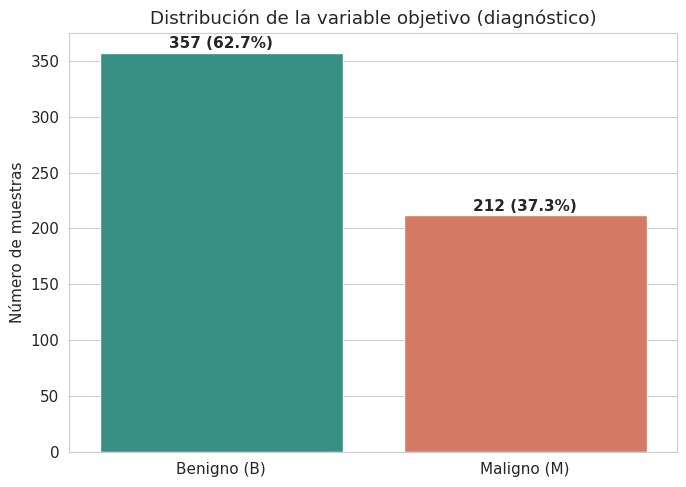

In [115]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df["target"].map(LABELS).value_counts()
sns.barplot(x=counts.index, y=counts.values, palette=["#2a9d8f", "#e76f51"], ax=ax)
for i, v in enumerate(counts.values):
    ax.text(i, v + 4, f"{v} ({100*v/len(df):.1f}%)", ha="center", fontweight="bold")
ax.set_title("Distribución de la variable objetivo (diagnóstico)")
ax.set_ylabel("Número de muestras"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(OUT_DIR / "01_distribucion_clases.png", dpi=120); plt.show()

## 6. Estadística descriptiva de las variables más relevantes

Mostramos un resumen de las variables de tipo *mean* (las 10 magnitudes promedio), que suelen ser las
más interpretables clínicamente.

In [116]:
mean_cols = [c for c in feature_cols if c.startswith("mean")]
df[mean_cols].describe().T[["mean", "std", "min", "50%", "max"]].round(3)

,mean,std,min,50%,max
mean radius,14.127,3.524,6.981,13.370,28.110
mean texture,19.290,4.301,9.710,18.840,39.280
mean perimeter,91.969,24.299,43.790,86.240,188.500
mean area,654.889,351.914,143.500,551.100,2501.000
mean smoothness,0.096,0.014,0.053,0.096,0.163
mean compactness,0.104,0.053,0.019,0.093,0.345
mean concavity,0.089,0.080,0.000,0.062,0.427
mean concave points,0.049,0.039,0.000,0.034,0.201
mean symmetry,0.181,0.027,0.106,0.179,0.304
mean fractal dimension,0.063,0.007,0.050,0.062,0.097


## 7. Correlación de cada variable con el objetivo y selección de características

Calculamos la correlación de Pearson de cada predictora con `target` y seleccionamos
las que superan un **umbral de |correlación| > 0.4** (correlación moderada-alta). Esta es nuestra
estrategia de **selección de características** para la versión mejorada de los modelos.

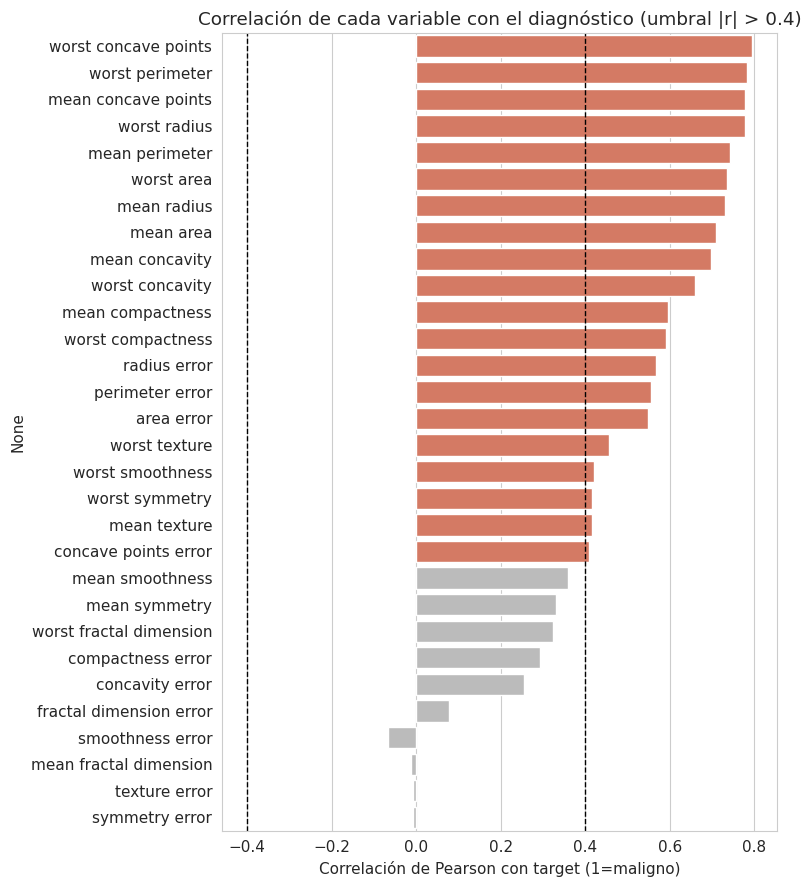

Variables seleccionadas (|r| > 0.4): 20 de 30
  worst concave points         r = +0.794
  worst perimeter              r = +0.783
  mean concave points          r = +0.777
  worst radius                 r = +0.776
  mean perimeter               r = +0.743
  worst area                   r = +0.734
  mean radius                  r = +0.730
  mean area                    r = +0.709
  mean concavity               r = +0.696
  worst concavity              r = +0.660
  mean compactness             r = +0.597
  worst compactness            r = +0.591
  radius error                 r = +0.567
  perimeter error              r = +0.556
  area error                   r = +0.548
  worst texture                r = +0.457
  worst smoothness             r = +0.421
  worst symmetry               r = +0.416
  mean texture                 r = +0.415
  concave points error         r = +0.408


In [117]:
corr_target = df.corr(numeric_only=True)["target"].drop("target").sort_values(key=np.abs, ascending=False)

THRESHOLD = 0.4
selected_features = corr_target[corr_target.abs() > THRESHOLD].index.tolist()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#e76f51" if abs(v) > THRESHOLD else "#bbbbbb" for v in corr_target.values]
sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors, ax=ax)
ax.axvline(THRESHOLD, color="k", ls="--", lw=1); ax.axvline(-THRESHOLD, color="k", ls="--", lw=1)
ax.set_title(f"Correlación de cada variable con el diagnóstico (umbral |r| > {THRESHOLD})")
ax.set_xlabel("Correlación de Pearson con target (1=maligno)")
plt.tight_layout(); plt.savefig(OUT_DIR / "02_correlacion_target.png", dpi=120); plt.show()

print(f"Variables seleccionadas (|r| > {THRESHOLD}): {len(selected_features)} de {len(feature_cols)}")
for f in selected_features:
    print(f"  {f:<28} r = {corr_target[f]:+.3f}")

## 8. Histogramas de las variables más predictivas

Comparamos la distribución de las 4 variables con mayor correlación, separadas por clase. Se observa
una **clara separación** entre malignos y benignos: los tumores malignos tienden a valores más altos
de tamaño/concavidad, lo que anticipa que el problema es **bien separable** linealmente; es decir, con poco solapamiento entre clases.

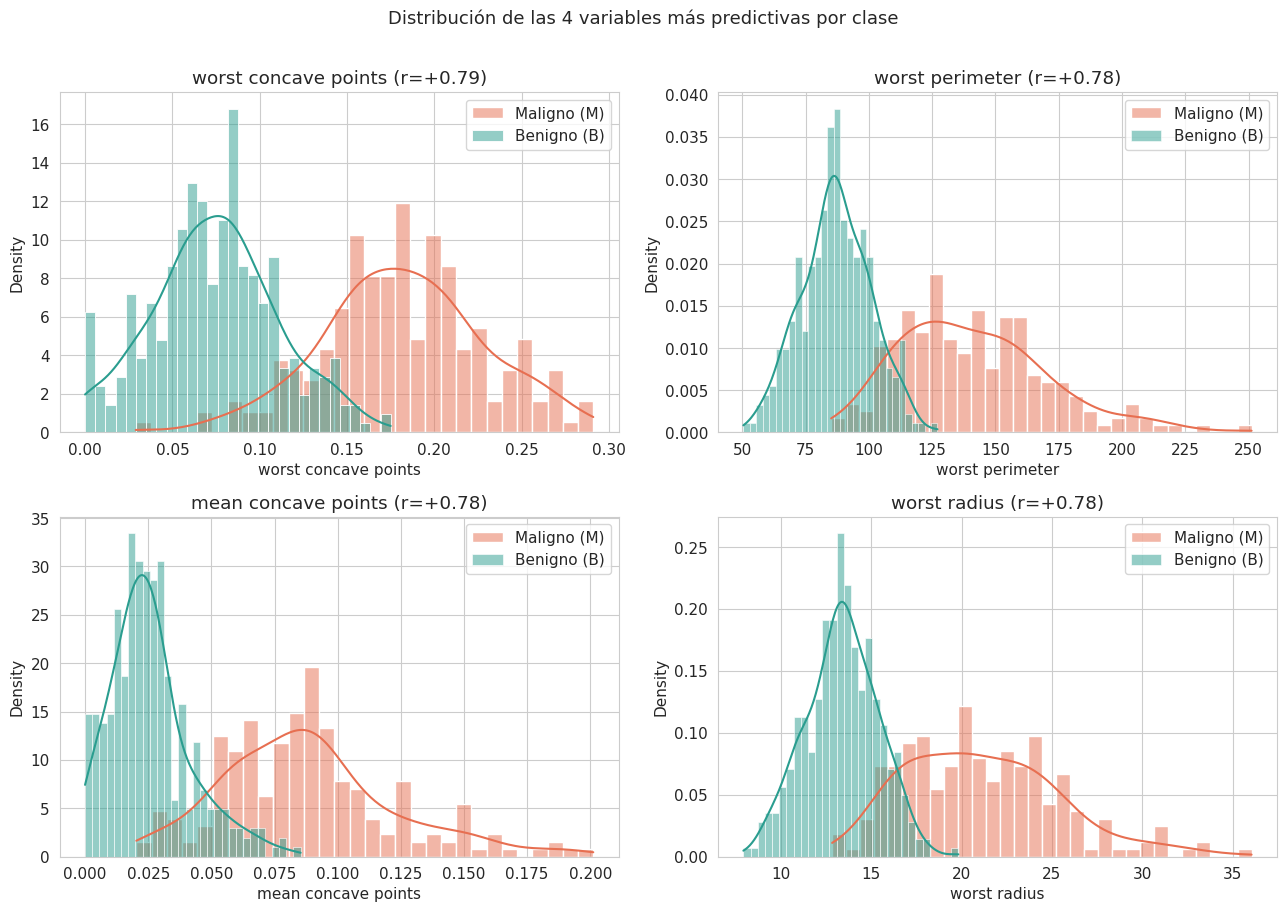

In [118]:
top4 = selected_features[:4]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), top4):
    for cls, color in [(1, "#e76f51"), (0, "#2a9d8f")]:
        sns.histplot(df[df.target == cls][col], ax=ax, color=color, label=LABELS[cls],
                     kde=True, stat="density", alpha=0.5, bins=30)
    ax.set_title(f"{col} (r={corr_target[col]:+.2f})"); ax.legend()
fig.suptitle("Distribución de las 4 variables más predictivas por clase", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "03_histogramas_top.png", dpi=120); plt.show()

## 9. Boxplots para detección visual de atípicos

Los boxplots confirman el análisis de la Fase I: existen valores extremos, **concentrados en la
clase maligna**. Esto sustenta la decisión de **no eliminarlos a ciegas**.

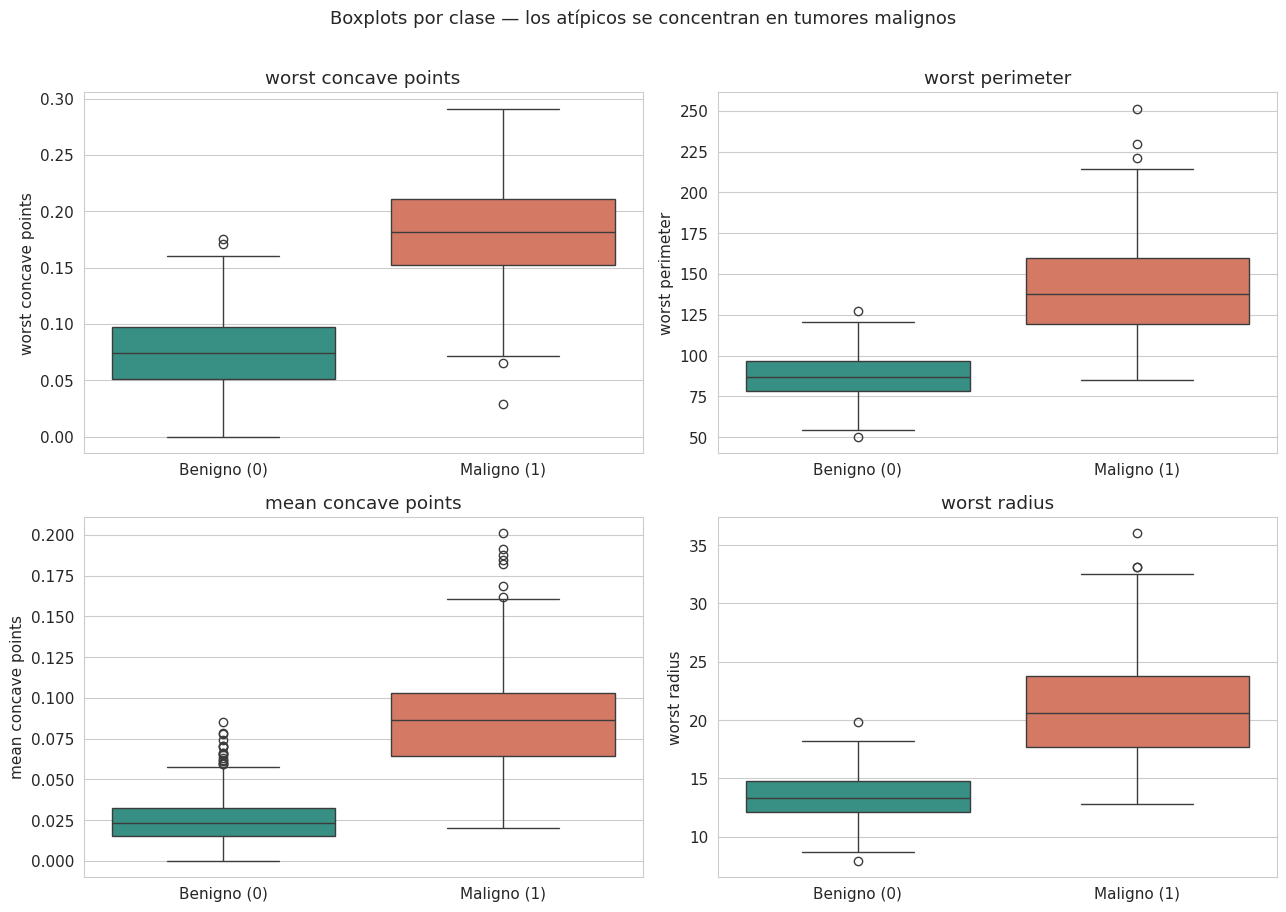

In [119]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), top4):
    sns.boxplot(data=df, x="target", y=col, palette=["#2a9d8f", "#e76f51"], ax=ax)
    ax.set_xticklabels(["Benigno (0)", "Maligno (1)"])
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle("Boxplots por clase — los atípicos se concentran en tumores malignos", y=1.01, fontsize=13)
plt.tight_layout(); plt.savefig(OUT_DIR / "04_boxplots.png", dpi=120); plt.show()

## 10. Matriz de correlación entre predictoras

Vamos a detectar la **multicolinealidad**. En el WBCD muchas variables son geométricamente
redundantes (p. ej. `mean radius`, `mean perimeter` y `mean area` miden esencialmente el tamaño y
correlacionan > 0.9). Esto justifica la selección de características y advierte que los coeficientes
de la Regresión Logística deben interpretarse con cautela.

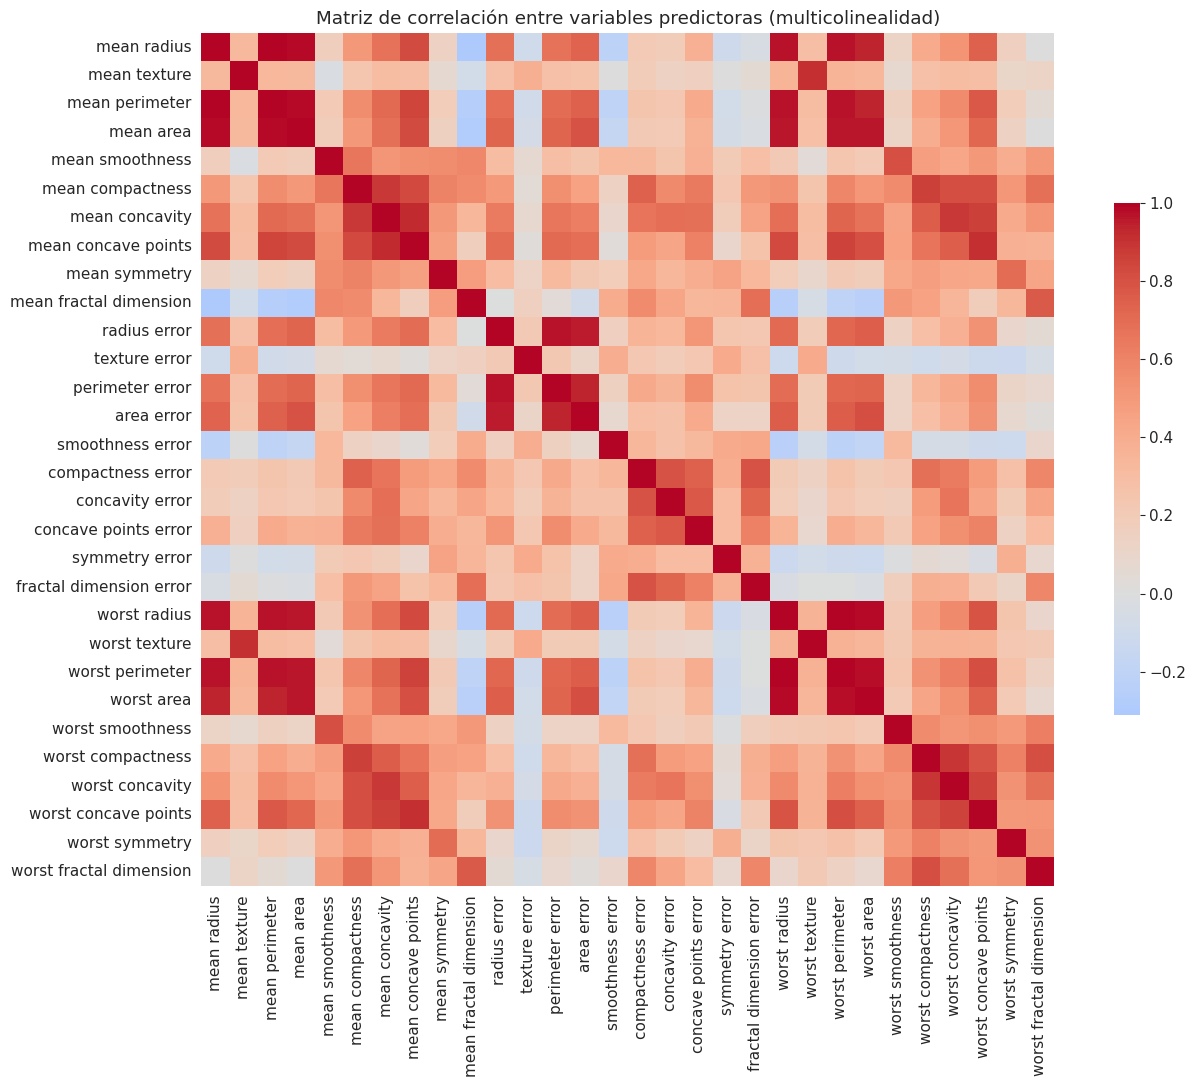

In [120]:
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Matriz de correlación entre variables predictoras (multicolinealidad)")
plt.tight_layout(); plt.savefig(OUT_DIR / "05_heatmap_correlacion.png", dpi=120); plt.show()

### Conclusiones del análisis:

- **Balance:** desbalance moderado (63% benigno / 37% maligno).
- **Variables más predictivas:** las relacionadas con **tamaño** (`worst perimeter`, `worst radius`,
  `worst area`) y **forma/concavidad** (`worst concave points`, `mean concave points`) son las de
  mayor correlación con malignidad (|r| > 0.7).
- **Multicolinealidad alta** entre variables de tamaño → justifica la selección por correlación y la
  cautela al interpretar coeficientes.
- **Separabilidad:** los histogramas muestran clases bien separadas.

---
# Fase III — Modelado y Evaluación

Entrenamos cuatro clasificadores clásicos, cada uno en dos versiones
(*baseline* y *mejorada*). Mantenemos un **conjunto de prueba intacto (20%)** con división
**estratificada** para que el balance de clases se conserve, y usamos `random_state=42` en todo.

## 11. División train/test y preparación de escaladores

- **División:** 80% entrenamiento / 20% prueba, **estratificada** por la clase.
- **Escalado:** ajustamos los escaladores **solo con los datos de entrenamiento** (para evitar fuga de
  información) y los aplicamos al test. Preparamos las dos versiones (`StandardScaler` y
  `MinMaxScaler`) para el experimento comparativo.

In [121]:
X = df[feature_cols].copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"Balance train: {dict(y_train.map(LABELS).value_counts())}")
print(f"Balance test : {dict(y_test.map(LABELS).value_counts())}")

# Escaladores ajustados SOLO con train
std_scaler = StandardScaler().fit(X_train)
mm_scaler  = MinMaxScaler().fit(X_train)

X_train_std, X_test_std = std_scaler.transform(X_train), std_scaler.transform(X_test)
X_train_mm,  X_test_mm  = mm_scaler.transform(X_train),  mm_scaler.transform(X_test)

Train: 455 muestras | Test: 114 muestras
Balance train: {'Benigno (B)': np.int64(285), 'Maligno (M)': np.int64(170)}
Balance test : {'Benigno (B)': np.int64(72), 'Maligno (M)': np.int64(42)}


In [122]:
from sklearn.model_selection import StratifiedKFold

# Índices de las variables seleccionadas (para versión mejorada)
sel_idx = [feature_cols.index(f) for f in selected_features]
# Validación cruzada estratificada para GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

X_train_sel_std = X_train_std[:, sel_idx]
X_test_sel_std = X_test_std[:, sel_idx]

## 12. Análisis con StandardScaler y MinMaxScaler

Antes de fijar el preprocesamiento comparamos ambos normalizadores sobre una Regresión Logística por
defecto, mirando el **recall** de la clase maligna. Si hay empate en recall, desempatamos por
idoneidad del método para el resto de algoritmos (KNN es de distancia).

In [123]:
scaler_results = []
for name, Xtr, Xte in [("StandardScaler", X_train_std, X_test_std),
                       ("MinMaxScaler",  X_train_mm,  X_test_mm)]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, y_train)
    pred = clf.predict(Xte)
    scaler_results.append({
        "Escalador": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Recall (maligno)": recall_score(y_test, pred),
        "F1 (maligno)": f1_score(y_test, pred),
    })
scaler_df = pd.DataFrame(scaler_results).round(4)
print(scaler_df.to_string(index=False))

     Escalador  Accuracy  Recall (maligno)  F1 (maligno)
StandardScaler    0.9649            0.9286        0.9512
  MinMaxScaler    0.9737            0.9286        0.9630


**Considerando el resultado anterior, el recall es idéntico con ambos escaladores. Se adopta StandardScaler como normalizador base por ser el más apropiado para los modelos de distancia (KNN) y lineales.**

## 13. Análisis: eliminar o conservar los atípicos

Comparamos el desempeño entrenando (a) con todos los datos y (b) eliminando del **entrenamiento** las
filas con atípicos. **Nunca** tocamos el conjunto de prueba. Dejamos que los datos decidan y
analizamos el resultado con criterio clínico, sin presuponer la conclusión.

In [124]:
# Máscara de atípicos calculada SOLO sobre el train (evita fuga)
train_outlier_mask, _ = iqr_outlier_mask(X_train.assign(target=y_train), feature_cols)
keep_idx = ~train_outlier_mask.values

exp_b = []
for label, Xtr, ytr in [("Conservar atípicos", X_train_std, y_train),
                         ("Eliminar atípicos",  X_train_std[keep_idx], y_train[keep_idx])]:
    clf = LogisticRegression(max_iter=5000, random_state=SEED).fit(Xtr, ytr)
    pred = clf.predict(X_test_std)
    exp_b.append({
        "Estrategia": label,
        "n_train": len(ytr),
        "Accuracy": accuracy_score(y_test, pred),
        "Recall (maligno)": recall_score(y_test, pred),
        "F1 (maligno)": f1_score(y_test, pred),
    })
exp_b_df = pd.DataFrame(exp_b).round(4)
print(exp_b_df.to_string(index=False))

        Estrategia  n_train  Accuracy  Recall (maligno)  F1 (maligno)
Conservar atípicos      455    0.9649            0.9286        0.9512
 Eliminar atípicos      320    0.9737            0.9286        0.9630


Considerando el resultado anterior, el recall (prioridad clínica) es IDÉNTICO en ambas estrategias; eliminar solo mejora de forma marginal accuracy/F1 en ESTA partición, a costa de descartar ~30% del entrenamiento y la señal de los tumores más agresivos. Por eso conservamos todos los datos: **no eliminamos ninguna fila.**

## 14. Funciones de evaluación reutilizables

Definimos utilidades para (a) calcular todas las métricas, (b) dibujar la matriz de confusión anotada con TN/FP/FN/TP y (c) dibujar la curva ROC con su AUC. Así el código de cada modelo queda limpio y consistente.

In [125]:
results = []   # se irá llenando con cada modelo/versión

def evaluate(model, Xte, yte, name, version, save_key=None):
    # Calcula todas las metricas, las registra en results y devuelve (dict, pred, proba)
    if isinstance(model, tf.keras.Model):
        proba_raw = model.predict(Xte, verbose=0)
        proba = proba_raw.ravel()
        # Convvertimos probabilidades a predicciones binarias (0 o 1) usando un umbral (ej. 0.5)
        pred = (proba > 0.5).astype(int)
    else: # Scikit-learn models
        pred = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1]

    row = {
        "Modelo": name, "Versión": version,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred),
        "Recall": recall_score(yte, pred),
        "F1": f1_score(yte, pred),
        "AUC": roc_auc_score(yte, proba),
    }
    results.append(row)
    return row, pred, proba

def plot_confusion(yte, pred, title, save_key=None):
    cm = confusion_matrix(yte, pred)
    tn, fp, fn, tp = cm.ravel()
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    labels = np.array([[f"TN\n{tn}", f"FP\n{fp}"], [f"FN\n{fn}", f"TP\n{tp}"]])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["Benigno (0)", "Maligno (1)"],
                yticklabels=["Benigno (0)", "Maligno (1)"], ax=ax)
    ax.set_xlabel("Predicción"); ax.set_ylabel("Real"); ax.set_title(title)
    plt.tight_layout()
    if save_key:
        plt.savefig(OUT_DIR / save_key, dpi=120)
    plt.show()
    return tn, fp, fn, tp

def plot_roc(curves, title, save_key=None):
    # curves: lista de tuplas (label, y_test, proba)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for label, yte, proba in curves:
        fpr, tpr, _ = roc_curve(yte, proba)
        auc = roc_auc_score(yte, proba)
        ax.plot(fpr, tpr, lw=2, label=f"{label} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
    ax.set_xlabel("Tasa de Falsos Positivos"); ax.set_ylabel("Tasa de Verdaderos Positivos (Recall)")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout()
    if save_key:
        plt.savefig(OUT_DIR / save_key, dpi=120)
    plt.show()

In [126]:
# Dictionaries to store the best models and their sizes
best_models = {}
model_sizes = {}

## 15. Modelo 1 — Regresión Logística

**Baseline:** hiperparámetros por defecto, todas las variables (escaladas con StandardScaler).
**Mejorada:** `GridSearchCV` sobre `solver`, `max_iter` y `C`, optimizando **recall** y usando solo
las variables seleccionadas (|r|>0.4).

In [127]:
import os

# Baseline: Logistic Regression sin GridSearchCV ni selección de características
logreg_base = LogisticRegression(max_iter=5000, random_state=SEED).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(logreg_base, X_test_std, y_test, "Reg. Logística", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# Mejorada: GridSearchCV + selección de características
param_grid_lr = {
    "solver": ["lbfgs", "saga", "newton-cg"],
    "max_iter": [100, 300, 500],
    "C": [0.1, 1, 10],
}
grid_lr = GridSearchCV(LogisticRegression(random_state=SEED), param_grid_lr,
                       scoring="recall", cv=cv, n_jobs=-1)
grid_lr.fit(X_train_std[:, sel_idx], y_train)
logreg_best = grid_lr.best_estimator_
row_m, pred_m, proba_m = evaluate(logreg_best, X_test_std[:, sel_idx], y_test, "Reg. Logística", "Mejorado")
print("Mejores hiperparámetros:", grid_lr.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

# Guardamos el modelo mejorado en disco y registramos su tamaño
model_filename_logreg = 'best_logistic_regression_model.joblib'
joblib.dump(logreg_best, MODELS_DIR / model_filename_logreg)
if 'model_sizes' not in locals():
    model_sizes = {} # Initialize if it doesn't exist
model_sizes['Reg. Logística'] = os.path.getsize(MODELS_DIR / model_filename_logreg) / (1024 * 1024)
print(f"Modelo de Reg. Logística guardado en '{model_filename_logreg}' (Tamaño: {model_sizes['Reg. Logística']:.4f} MB)")

BASELINE: {'Accuracy': 0.9649, 'Precision': 0.975, 'Recall': 0.9286, 'F1': 0.9512, 'AUC': np.float64(0.996)}
Mejores hiperparámetros: {'C': 10, 'max_iter': 500, 'solver': 'saga'}
MEJORADO: {'Accuracy': 0.9825, 'Precision': 0.9762, 'Recall': 0.9762, 'F1': 0.9762, 'AUC': np.float64(0.9954)}
Modelo de Reg. Logística guardado en 'best_logistic_regression_model.joblib' (Tamaño: 0.0010 MB)


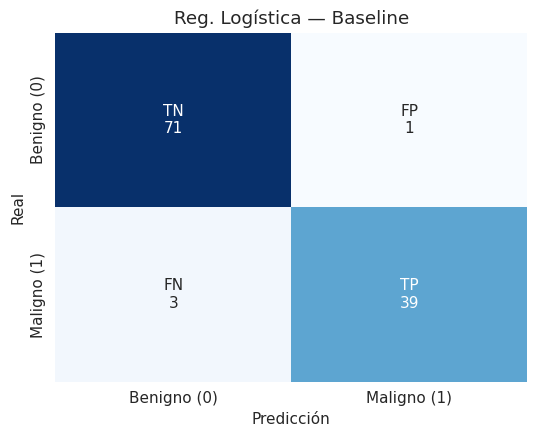

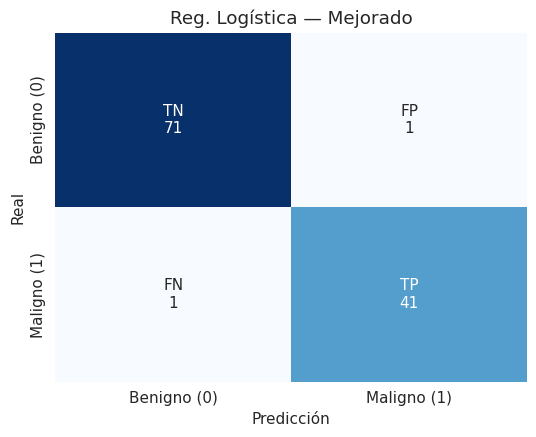

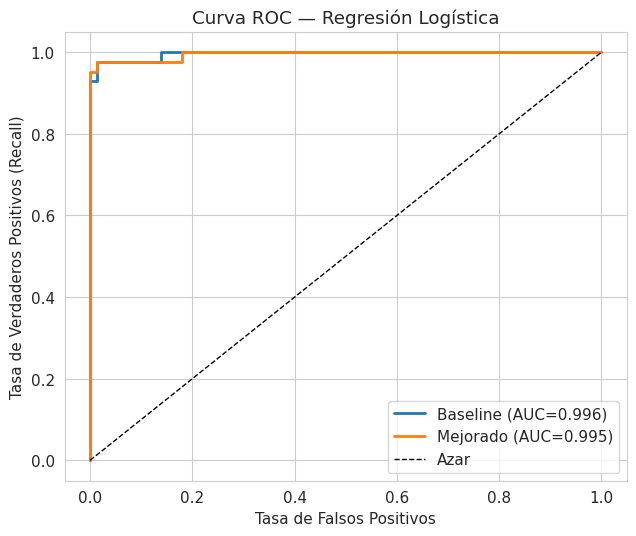

In [128]:
plot_confusion(y_test, pred_b, "Reg. Logística — Baseline", "06_cm_logreg_baseline.png")
plot_confusion(y_test, pred_m, "Reg. Logística — Mejorado", "07_cm_logreg_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Regresión Logística", "08_roc_logreg.png")

### Importancia de características (coeficientes) — análisis adicional

Los coeficientes de la Regresión Logística mejorada indican qué variables empujan la predicción hacia **maligno** (positivos) o **benigno** (negativos). Es una forma directa de *interpretabilidad* del
modelo lineal.

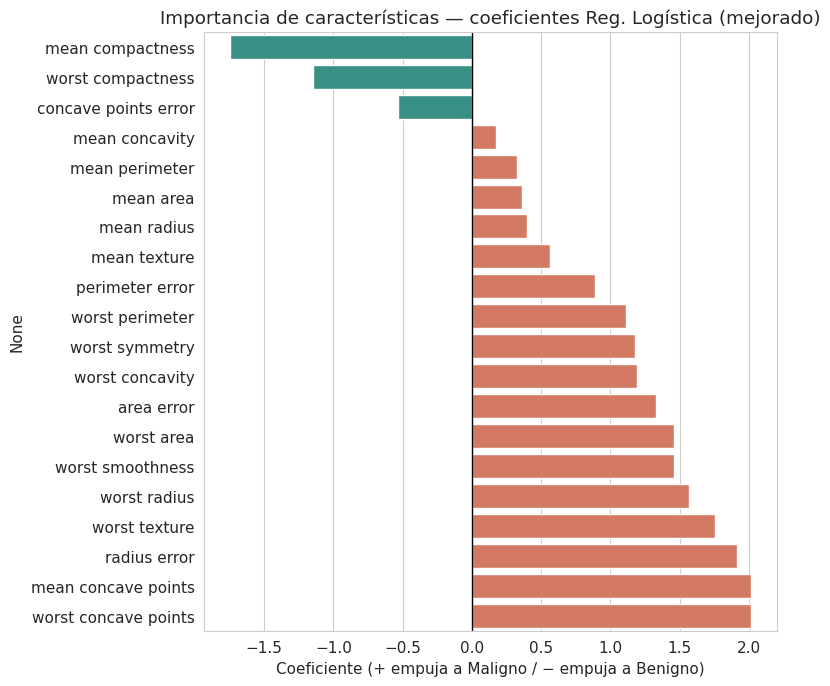

In [129]:
coefs = pd.Series(logreg_best.coef_[0], index=selected_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#2a9d8f" if c < 0 else "#e76f51" for c in coefs.values]
sns.barplot(x=coefs.values, y=coefs.index, palette=colors, ax=ax)
ax.axvline(0, color="k", lw=1)
ax.set_title("Importancia de características — coeficientes Reg. Logística (mejorado)")
ax.set_xlabel("Coeficiente (+ empuja a Maligno / − empuja a Benigno)")
plt.tight_layout(); plt.savefig(OUT_DIR / "09_importancia_logreg.png", dpi=120); plt.show()

## 16. Modelo 2 — K-Nearest Neighbors (KNN)

> **Nota:** KNN se basa en distancias, por lo que **siempre** debe normalizarse. Usamos los datos
> escalados con StandardScaler.

**Baseline:** `k=5` por defecto, todas las variables. **Mejorada:** `GridSearchCV` sobre
`n_neighbors`, `metric` y `weights`, con selección de características.

In [130]:
# Baseline: KNN sin GridSearchCV ni selección de características
knn_base = KNeighborsClassifier().fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(knn_base, X_test_std, y_test, "KNN", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# Mejorada: GridSearchCV + selección de características
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "metric": ["euclidean", "manhattan"],
    "weights": ["uniform", "distance"],
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                        scoring="recall", cv=cv, n_jobs=-1)
grid_knn.fit(X_train_std[:, sel_idx], y_train)
knn_best = grid_knn.best_estimator_
row_m, pred_m, proba_m = evaluate(knn_best, X_test_std[:, sel_idx], y_test, "KNN", "Mejorado")
print("Mejores hiperparámetros:", grid_knn.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

# Guardamos el modelo mejorado en disco y registramos su tamaño
model_filename_knn = 'best_knn_model.joblib'
joblib.dump(knn_best, MODELS_DIR / model_filename_knn)
if 'model_sizes' not in locals():
    model_sizes = {} # Initialize if it doesn't exist
model_sizes['KNN'] = os.path.getsize(MODELS_DIR / model_filename_knn) / (1024 * 1024)
print(f"Modelo de KNN guardado en '{model_filename_knn}' (Tamaño: {model_sizes['KNN']:.4f} MB)")

BASELINE: {'Accuracy': 0.9561, 'Precision': 0.9744, 'Recall': 0.9048, 'F1': 0.9383, 'AUC': np.float64(0.9823)}
Mejores hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
MEJORADO: {'Accuracy': 0.9649, 'Precision': 1.0, 'Recall': 0.9048, 'F1': 0.95, 'AUC': np.float64(0.9861)}
Modelo de KNN guardado en 'best_knn_model.joblib' (Tamaño: 0.0737 MB)


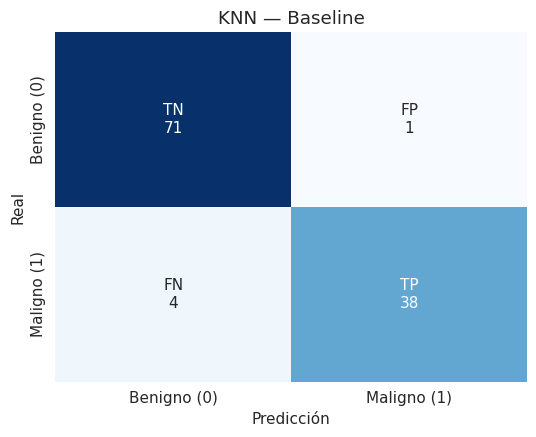

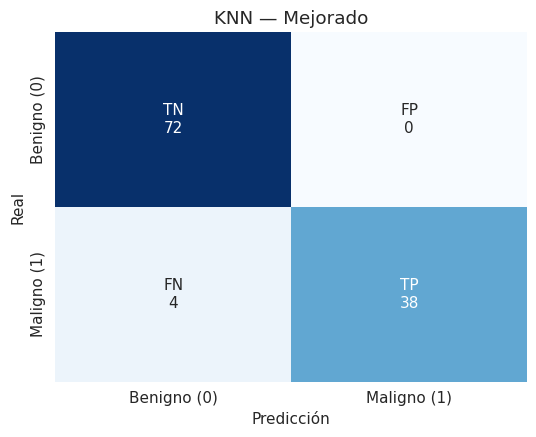

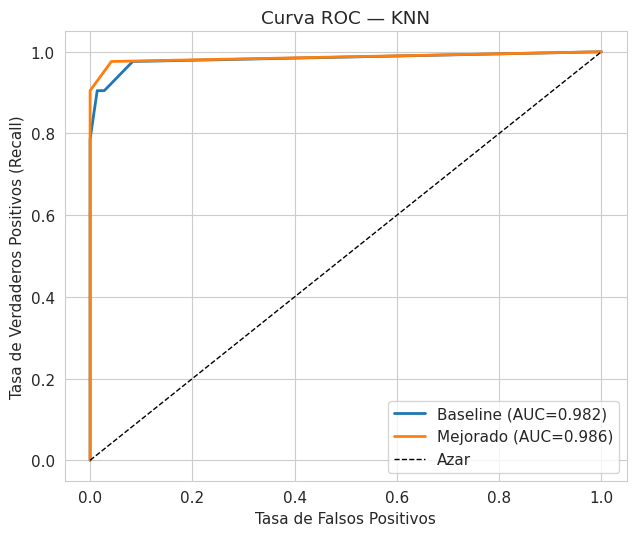

In [131]:
plot_confusion(y_test, pred_b, "KNN — Baseline", "10_cm_knn_baseline.png")
plot_confusion(y_test, pred_m, "KNN — Mejorado", "11_cm_knn_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — KNN", "12_roc_knn.png")

## 17. Modelo 3 — Naive Bayes Gaussiano (GaussianNB)

**Baseline:** por defecto, todas las variables. **Mejorada:** `GridSearchCV` sobre `var_smoothing` con selección de características.

In [132]:
# Baseline: Naive Bayes sin GridSearchCV ni selección de características
nb_base = GaussianNB().fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(nb_base, X_test_std, y_test, "Naive Bayes", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# Mejorada: GridSearchCV + selección de características
param_grid_nb = {"var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}
grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, scoring="recall", cv=cv, n_jobs=-1)
grid_nb.fit(X_train_std[:, sel_idx], y_train)
nb_best = grid_nb.best_estimator_
row_m, pred_m, proba_m = evaluate(nb_best, X_test_std[:, sel_idx], y_test, "Naive Bayes", "Mejorado")
print("Mejores hiperparámetros:", grid_nb.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

# Guardamos el modelo mejorado en disco y registramos su tamaño
model_filename_nb = 'best_naive_bayes_model.joblib'
joblib.dump(nb_best, MODELS_DIR / model_filename_nb)
if 'model_sizes' not in locals():
    model_sizes = {} # Initialize if it doesn't exist
model_sizes['Naive Bayes'] = os.path.getsize(MODELS_DIR / model_filename_nb) / (1024 * 1024)
print(f"Modelo de Naive Bayes guardado en '{model_filename_nb}' (Tamaño: {model_sizes['Naive Bayes']:.4f} MB)")

BASELINE: {'Accuracy': 0.9211, 'Precision': 0.9231, 'Recall': 0.8571, 'F1': 0.8889, 'AUC': np.float64(0.9891)}
Mejores hiperparámetros: {'var_smoothing': 1e-09}
MEJORADO: {'Accuracy': 0.9386, 'Precision': 0.973, 'Recall': 0.8571, 'F1': 0.9114, 'AUC': np.float64(0.9921)}
Modelo de Naive Bayes guardado en 'best_naive_bayes_model.joblib' (Tamaño: 0.0013 MB)


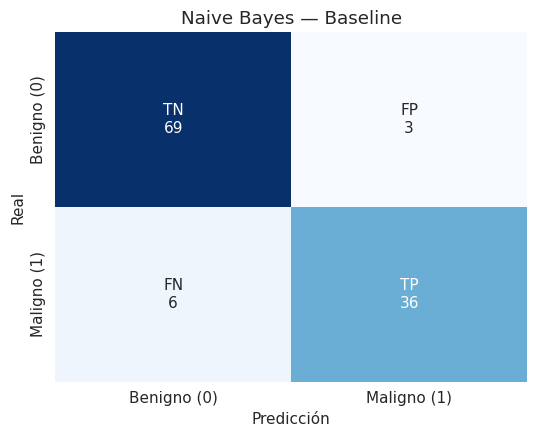

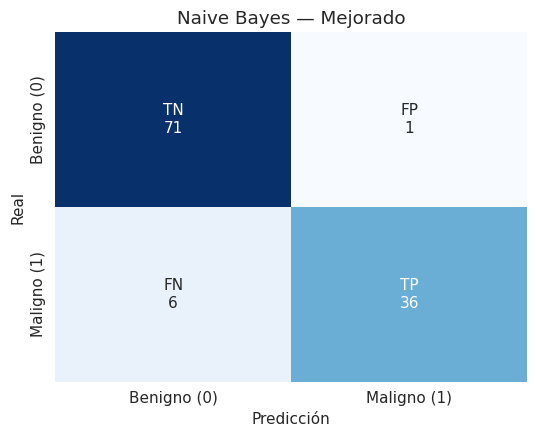

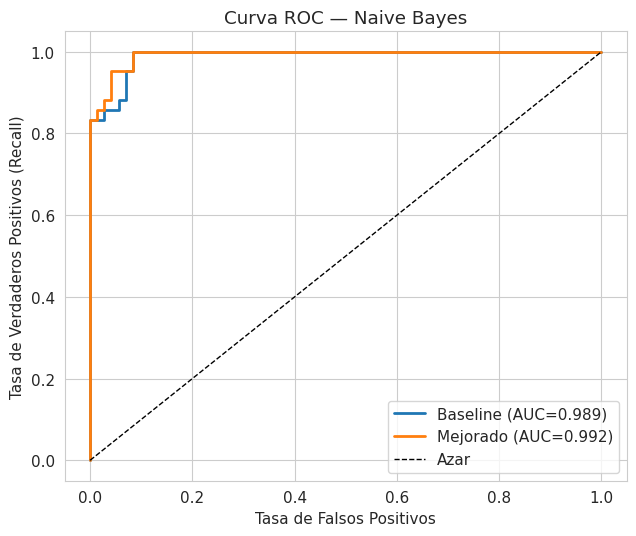

In [133]:
plot_confusion(y_test, pred_b, "Naive Bayes — Baseline", "13_cm_nb_baseline.png")
plot_confusion(y_test, pred_m, "Naive Bayes — Mejorado", "14_cm_nb_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Naive Bayes", "15_roc_nb.png")

## 18. Modelo 4 — Random Forest (propuesta del equipo)

**Baseline:** por defecto, todas las variables. **Mejorada:** `GridSearchCV` sobre `n_estimators`,
`max_depth`, `min_samples_split` y `max_features`, optimizando **recall**, con selección de variables.

In [134]:
from sklearn.ensemble import RandomForestClassifier

# Baseline: Random Forest sin GridSearchCV ni selección de características
rf_base = RandomForestClassifier(random_state=SEED).fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(rf_base, X_test_std, y_test, "Random Forest", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# Mejorada: GridSearchCV + selección de características
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"],
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid_rf,
                       scoring="recall", cv=cv, n_jobs=-1)
grid_rf.fit(X_train_std[:, sel_idx], y_train)
rf_best = grid_rf.best_estimator_
row_m, pred_m, proba_m = evaluate(rf_best, X_test_std[:, sel_idx], y_test, "Random Forest", "Mejorado")
print("Mejores hiperparámetros:", grid_rf.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

# Guardamos el modelo mejorado en disco y registramos su tamaño
model_filename_rf = 'best_random_forest_model.joblib'
joblib.dump(rf_best, MODELS_DIR / model_filename_rf)
if 'model_sizes' not in locals():
    model_sizes = {} # Initialize if it doesn't exist
model_sizes['Random Forest'] = os.path.getsize(MODELS_DIR / model_filename_rf) / (1024 * 1024)
print(f"Modelo de Random Forest guardado en '{model_filename_rf}' (Tamaño: {model_sizes['Random Forest']:.4f} MB)")

BASELINE: {'Accuracy': 0.9737, 'Precision': 1.0, 'Recall': 0.9286, 'F1': 0.963, 'AUC': np.float64(0.9929)}
Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
MEJORADO: {'Accuracy': 0.9649, 'Precision': 1.0, 'Recall': 0.9048, 'F1': 0.95, 'AUC': np.float64(0.9937)}
Modelo de Random Forest guardado en 'best_random_forest_model.joblib' (Tamaño: 0.3107 MB)


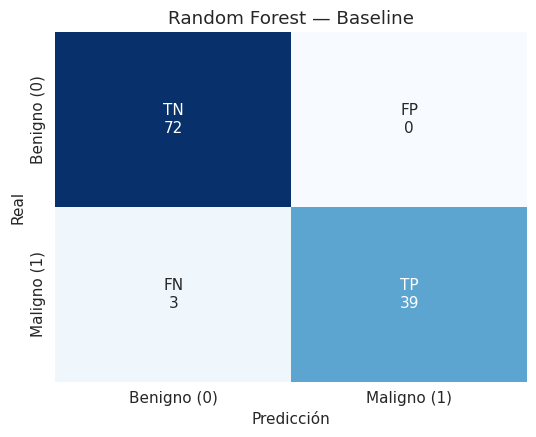

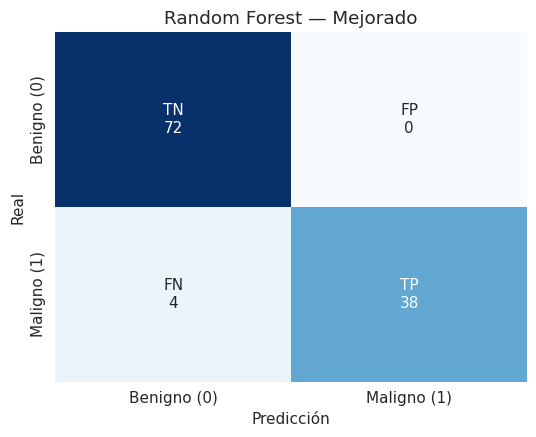

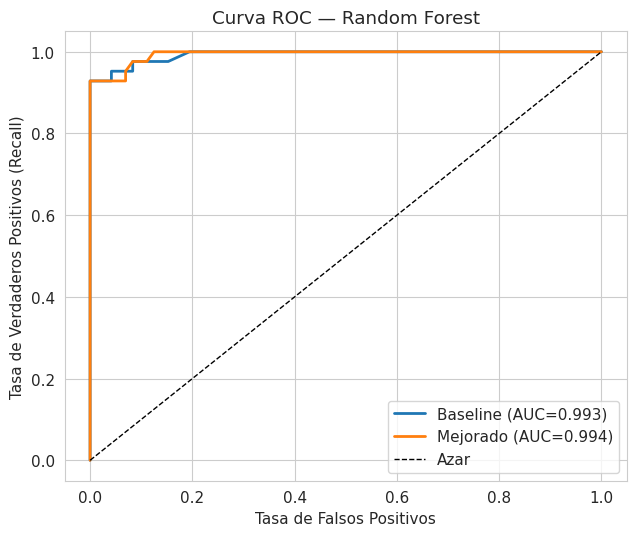

In [135]:
plot_confusion(y_test, pred_b, "Random Forest — Baseline", "16_cm_rf_baseline.png")
plot_confusion(y_test, pred_m, "Random Forest — Mejorado", "17_cm_rf_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Random Forest", "18_roc_rf.png")

### Importancia de características (Random Forest, Gini) — análisis adicional

Random Forest mide la importancia por la **reducción de impureza (Gini)**. Contrastarla con los
coeficientes lineales enriquece la interpretabilidad del diagnóstico.

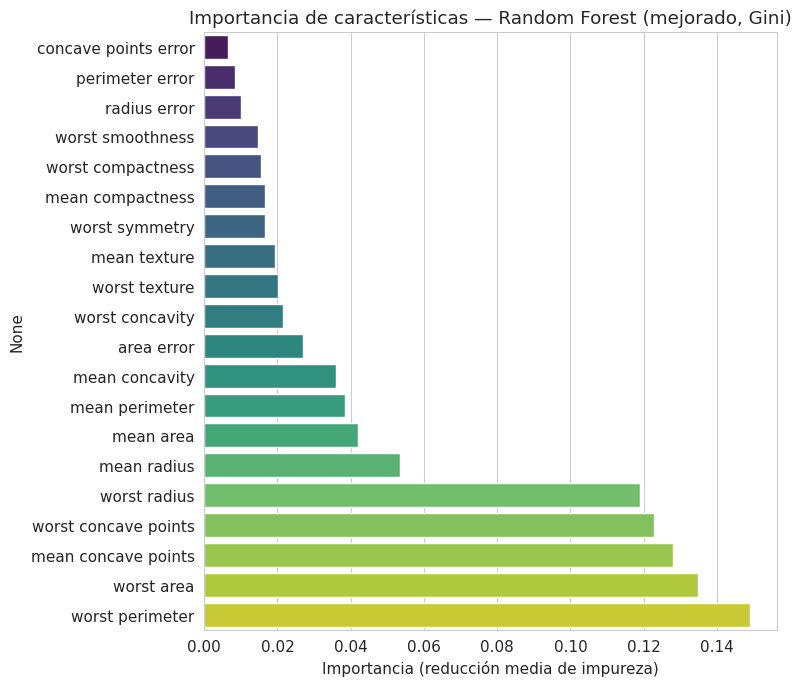

In [136]:
rf_imp = pd.Series(rf_best.feature_importances_, index=selected_features).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=rf_imp.values, y=rf_imp.index, palette="viridis", ax=ax)
ax.set_title("Importancia de características — Random Forest (mejorado, Gini)")
ax.set_xlabel("Importancia (reducción media de impureza)")
plt.tight_layout(); plt.savefig(OUT_DIR / "19_importancia_rf.png", dpi=120); plt.show()

**Comparación baseline vs mejorado (Random Forest):** el ensamble rinde muy bien ya en *baseline*; de
hecho su baseline supera a la versión optimizada en recall sobre el test. Es un recordatorio de que **el
óptimo hallado por validación cruzada no siempre transfiere al conjunto de prueba**.

## 19. Modelo 5 — Árbol de Decisión

**Baseline:** hiperparámetros por defecto, todas las variables (escaladas con StandardScaler).
**Mejorada:** `RandomizedSearchCV` sobre `max_depth`, `min_samples_leaf` y `criterion`, optimizando **recall** y usando solo
las variables seleccionadas (|r|>0.4).

BASELINE: {'Accuracy': 0.9298, 'Precision': 0.9048, 'Recall': 0.9048, 'F1': 0.9048, 'AUC': np.float64(0.9246)}
Mejores hiperparámetros: {'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'gini'}
MEJORADO: {'Accuracy': 0.9298, 'Precision': 0.925, 'Recall': 0.881, 'F1': 0.9024, 'AUC': np.float64(0.9196)}


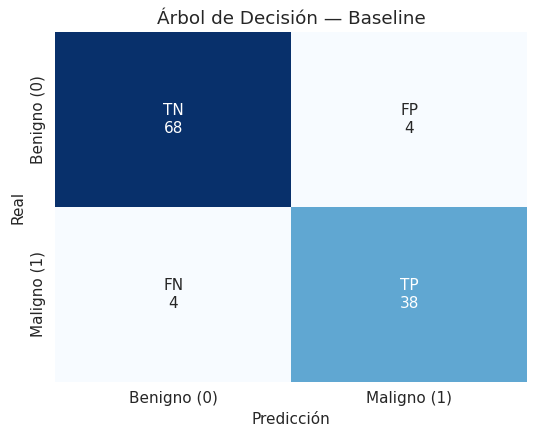

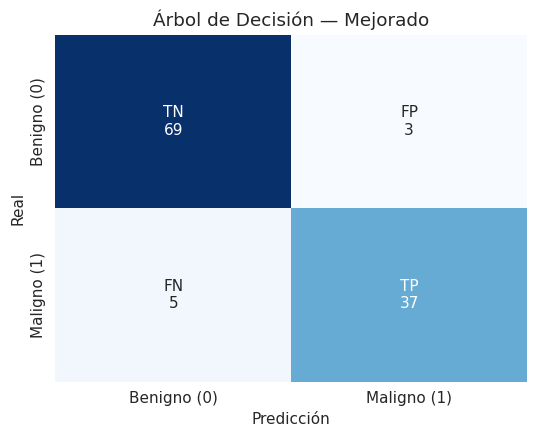

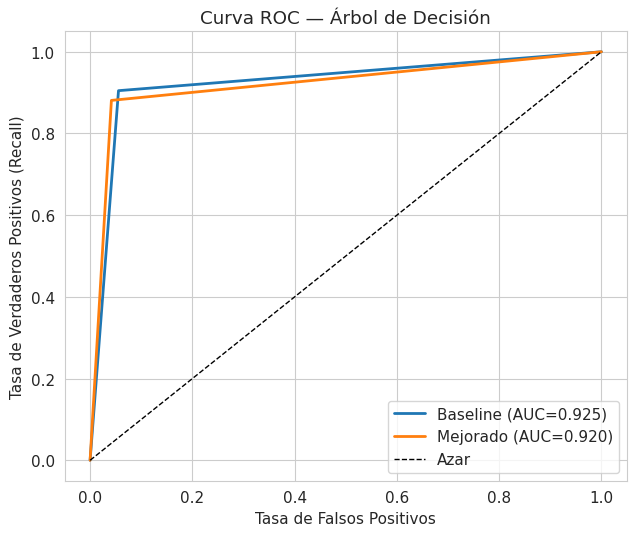

Modelo de Árbol de Decisión guardado en 'best_dtree_model.joblib' (Tamaño: 0.0048 MB)


In [137]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Baseline: Árbol de Decisión sin GridSearchCV ni selección de características
dtree_base = DecisionTreeClassifier(random_state=SEED)
dtree_base.fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(dtree_base, X_test_std, y_test, "Árbol de Decisión", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# Mejorada: RandomizedSearchCV + selección de características
param_distributions_dt = {
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"],
}

random_search_dt = RandomizedSearchCV(DecisionTreeClassifier(random_state=SEED), param_distributions_dt,
                                      n_iter=20, scoring="recall", cv=cv, n_jobs=-1, random_state=SEED)
random_search_dt.fit(X_train_std[:, sel_idx], y_train)
dtree_best = random_search_dt.best_estimator_
row_m, pred_m, proba_m = evaluate(dtree_best, X_test_std[:, sel_idx], y_test, "Árbol de Decisión", "Mejorado")
print("Mejores hiperparámetros:", random_search_dt.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

plot_confusion(y_test, pred_b, "Árbol de Decisión — Baseline", "dtree_cm_baseline.png")
plot_confusion(y_test, pred_m, "Árbol de Decisión — Mejorado", "dtree_cm_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Árbol de Decisión", "dtree_roc.png")

# Guardamos el modelo mejorado en disco y registramos su tamaño
recall_dtree = recall_score(y_test, pred_m)
f1_dtree = f1_score(y_test, pred_m)
model_filename_dtree = 'best_dtree_model.joblib'
joblib.dump(dtree_best, MODELS_DIR / model_filename_dtree)

if 'model_sizes' not in locals():
    model_sizes = {} # Initialize if it doesn't exist
model_sizes['Árbol de Decisión'] = os.path.getsize(MODELS_DIR / model_filename_dtree) / (1024 * 1024)
print(f"Modelo de Árbol de Decisión guardado en '{model_filename_dtree}' (Tamaño: {model_sizes['Árbol de Decisión']:.4f} MB)")

### Visualización del Árbol de Decisión

Aquí se muestra una visualización del árbol de decisión entrenado. Los nodos de decisión indican la característica y el umbral utilizados para dividir los datos, mientras que las hojas muestran la clase predicha.

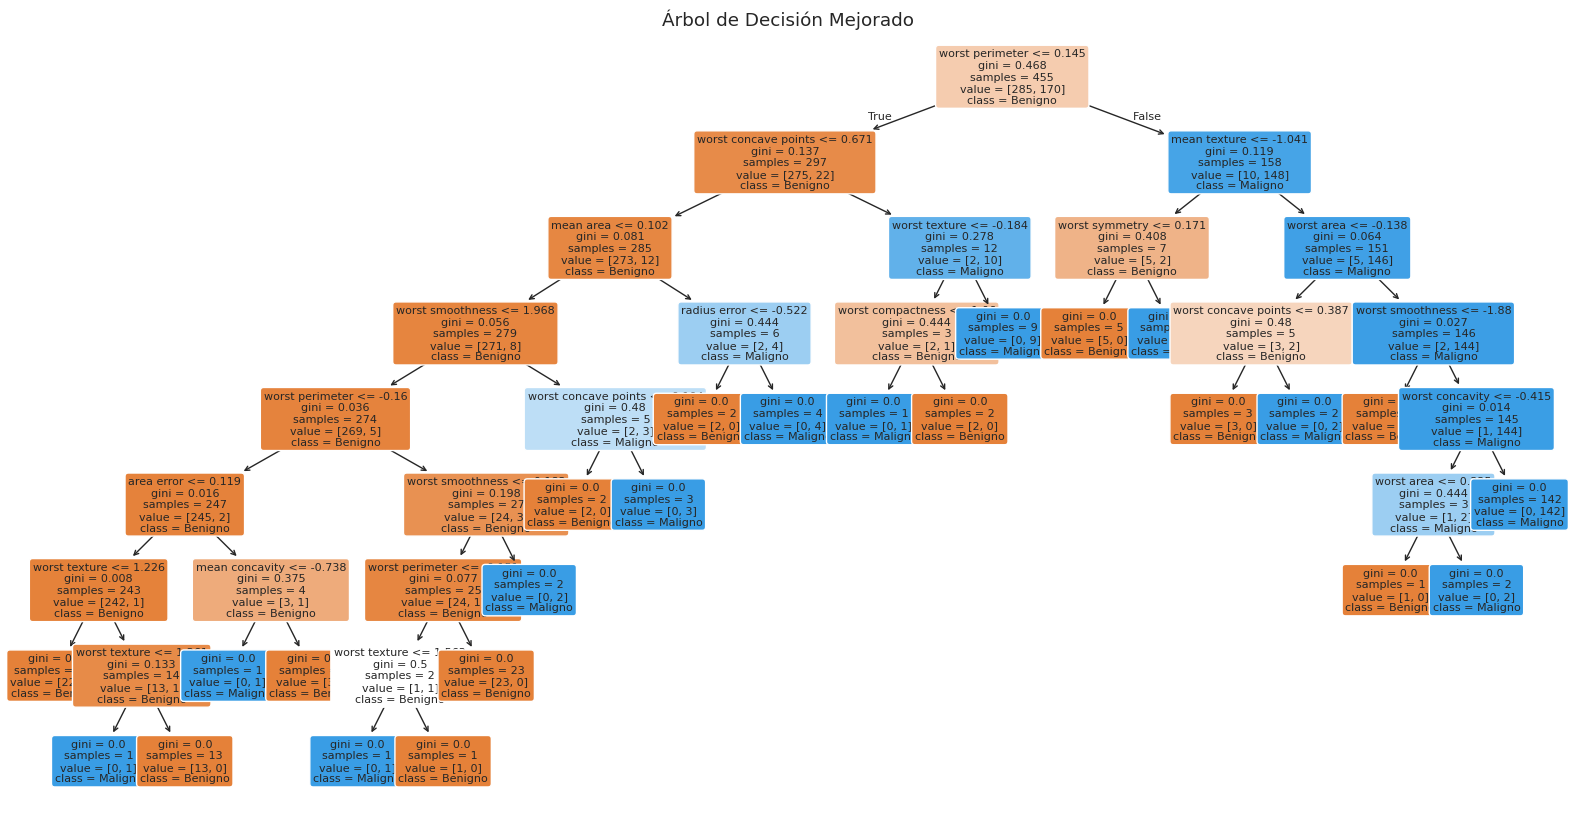

In [145]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dtree_best,
          feature_names=selected_features,
          class_names=['Benigno', 'Maligno'],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Árbol de Decisión Mejorado')
plt.savefig(OUT_DIR / "dtree_plot.png", dpi=300)
plt.show()

### Importancia de características (Árbol de Decisión, Gini) — análisis adicional

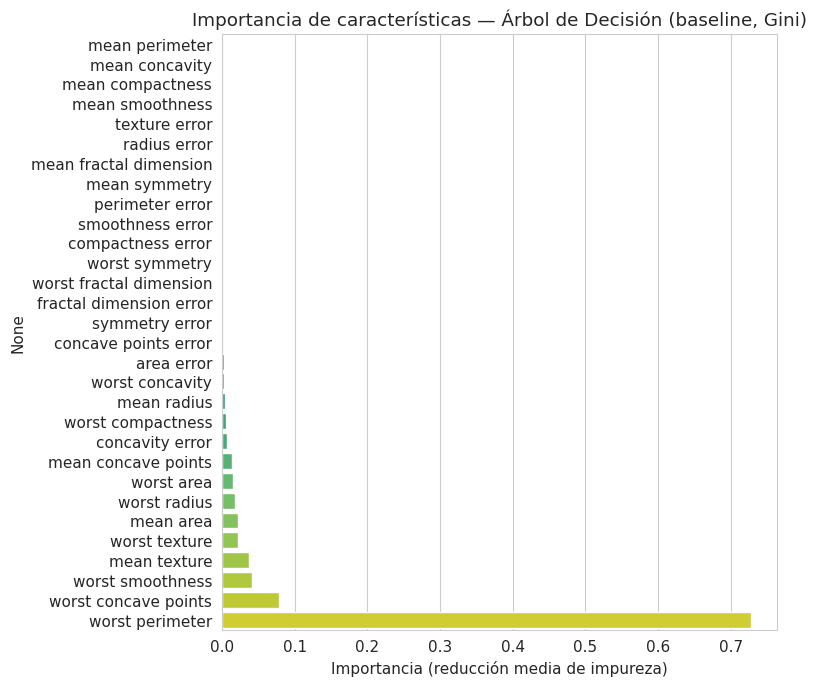

In [138]:
dtree_imp = pd.Series(dtree_base.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=dtree_imp.values, y=dtree_imp.index, palette="viridis", ax=ax)
ax.set_title("Importancia de características — Árbol de Decisión (baseline, Gini)")
ax.set_xlabel("Importancia (reducción media de impureza)")
plt.tight_layout(); plt.savefig(OUT_DIR / "dtree_importancia_baseline.png", dpi=120); plt.show()

## 21. Modelo 7 — Máquinas de Vectores de Soporte (SVM)

**Baseline:** hiperparámetros por defecto, todas las variables (escaladas con StandardScaler).
**Mejorada:** `RandomizedSearchCV` sobre `C`, `kernel` y `gamma`, optimizando **recall**, con selección de variables.

BASELINE: {'Accuracy': 0.9737, 'Precision': 1.0, 'Recall': 0.9286, 'F1': 0.963, 'AUC': np.float64(0.9947)}
Mejores hiperparámetros: {'kernel': 'rbf', 'gamma': 1, 'C': 1}
MEJORADO: {'Accuracy': 0.9123, 'Precision': 0.8333, 'Recall': 0.9524, 'F1': 0.8889, 'AUC': np.float64(0.9745)}


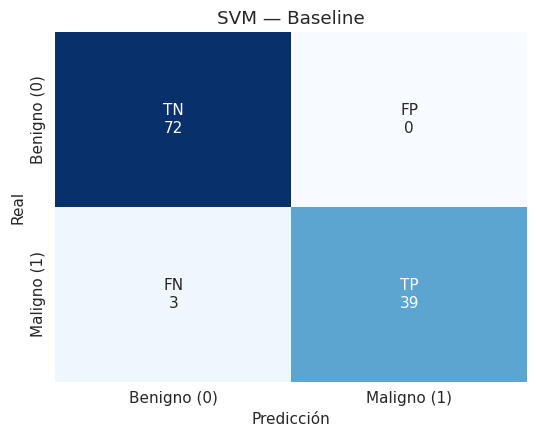

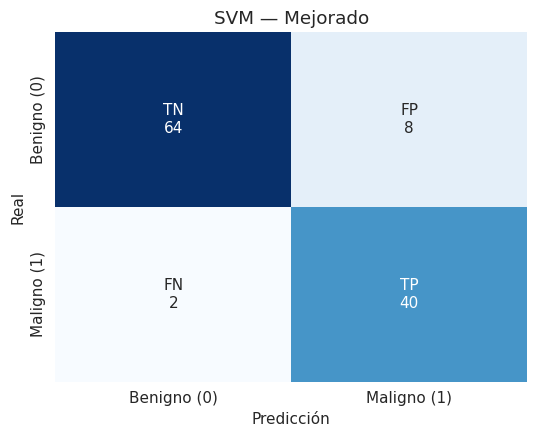

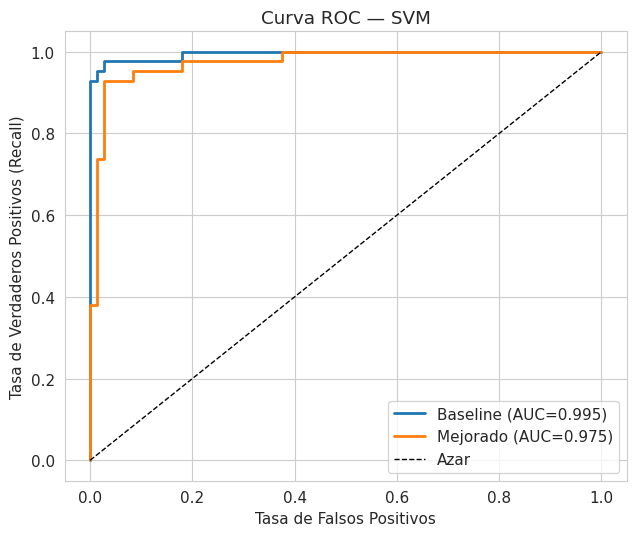

Modelo de SVM guardado en 'best_svm_model.joblib' (Tamaño: 0.0716 MB)


In [139]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
import os

# Baseline: SVM sin GridSearchCV ni selección de características
svm_base = SVC(random_state=SEED, probability=True) # probability=True para tener predict_proba
svm_base.fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(svm_base, X_test_std, y_test, "SVM", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# Mejorada: RandomizedSearchCV + selección de características
param_distributions_svm = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly", "sigmoid"],
    "gamma": ["scale", "auto", 0.1, 1, 10],
}

random_search_svm = RandomizedSearchCV(SVC(random_state=SEED, probability=True), param_distributions_svm,
                                       n_iter=20, scoring="recall", cv=cv, n_jobs=-1, random_state=SEED)
random_search_svm.fit(X_train_std[:, sel_idx], y_train)
svm_best = random_search_svm.best_estimator_
row_m, pred_m, proba_m = evaluate(svm_best, X_test_std[:, sel_idx], y_test, "SVM", "Mejorado")
print("Mejores hiperparámetros:", random_search_svm.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

plot_confusion(y_test, pred_b, "SVM — Baseline", "svm_cm_baseline.png")
plot_confusion(y_test, pred_m, "SVM — Mejorado", "svm_cm_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — SVM", "svm_roc.png")

# Guardamos el modelo mejorado en disco y registramos su tamaño
recall_svm = recall_score(y_test, pred_m)
f1_svm = f1_score(y_test, pred_m)
model_filename_svm = 'best_svm_model.joblib'
joblib.dump(svm_best, MODELS_DIR / model_filename_svm)

if 'model_sizes' not in locals():
    model_sizes = {}
model_sizes['SVM'] = os.path.getsize(MODELS_DIR / model_filename_svm) / (1024 * 1024)
print(f"Modelo de SVM guardado en '{model_filename_svm}' (Tamaño: {model_sizes['SVM']:.4f} MB)")

## 22. Modelo 8 — Gradient Boosting Classifier

**Baseline:** hiperparámetros por defecto, todas las variables (escaladas con StandardScaler).
**Mejorada:** `RandomizedSearchCV` sobre `n_estimators`, `learning_rate`, `max_depth` y `subsample`, optimizando **recall**, con selección de variables.

BASELINE: {'Accuracy': 0.9649, 'Precision': 1.0, 'Recall': 0.9048, 'F1': 0.95, 'AUC': np.float64(0.9947)}
Mejores hiperparámetros: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.2}
MEJORADO: {'Accuracy': 0.9649, 'Precision': 1.0, 'Recall': 0.9048, 'F1': 0.95, 'AUC': np.float64(0.9964)}


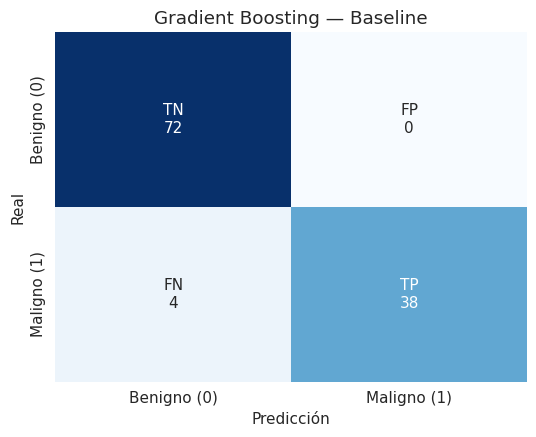

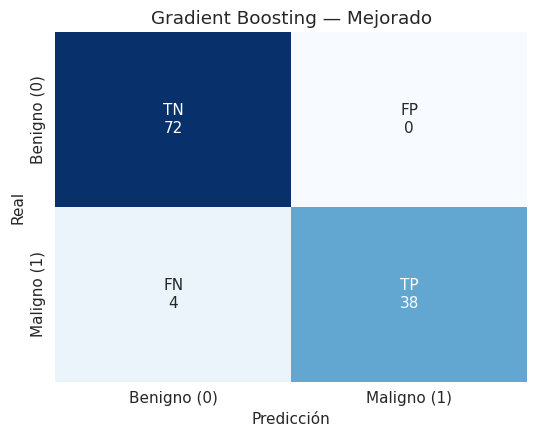

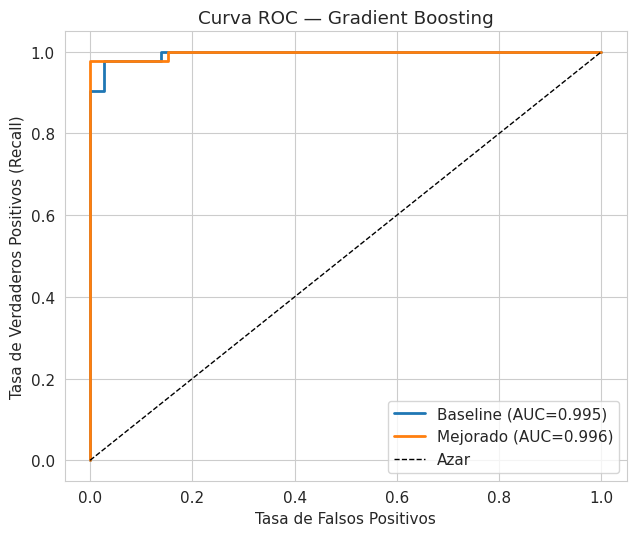

Modelo de Gradient Boosting guardado en 'best_gbm_model.joblib' (Tamaño: 0.0725 MB)


In [140]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import os

# Baseline: Gradient Boosting sin GridSearchCV ni selección de características
gbm_base = GradientBoostingClassifier(random_state=SEED)
gbm_base.fit(X_train_std, y_train)
row_b, pred_b, proba_b = evaluate(gbm_base, X_test_std, y_test, "Gradient Boosting", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_b.items() if isinstance(v, float)})

# Mejorada: RandomizedSearchCV + selección de características
param_distributions_gbm = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.6, 0.8, 1.0],
}

random_search_gbm = RandomizedSearchCV(GradientBoostingClassifier(random_state=SEED), param_distributions_gbm,
                                       n_iter=20, scoring="recall", cv=cv, n_jobs=-1, random_state=SEED)
random_search_gbm.fit(X_train_std[:, sel_idx], y_train)
gbm_best = random_search_gbm.best_estimator_
row_m, pred_m, proba_m = evaluate(gbm_best, X_test_std[:, sel_idx], y_test, "Gradient Boosting", "Mejorado")
print("Mejores hiperparámetros:", random_search_gbm.best_params_)
print("MEJORADO:", {k: round(v, 4) for k, v in row_m.items() if isinstance(v, float)})

plot_confusion(y_test, pred_b, "Gradient Boosting — Baseline", "gbm_cm_baseline.png")
plot_confusion(y_test, pred_m, "Gradient Boosting — Mejorado", "gbm_cm_mejorado.png")
plot_roc([("Baseline", y_test, proba_b), ("Mejorado", y_test, proba_m)],
         "Curva ROC — Gradient Boosting", "gbm_roc.png")

# 5. Guardar métricas y tamaño del modelo
recall_gbm = recall_score(y_test, pred_m)
f1_gbm = f1_score(y_test, pred_m)
model_filename_gbm = 'best_gbm_model.joblib'
joblib.dump(gbm_best, MODELS_DIR / model_filename_gbm)

if 'model_sizes' not in locals():
    model_sizes = {}
model_sizes['Gradient Boosting'] = os.path.getsize(MODELS_DIR / model_filename_gbm) / (1024 * 1024)
print(f"Modelo de Gradient Boosting guardado en '{model_filename_gbm}' (Tamaño: {model_sizes['Gradient Boosting']:.4f} MB)")

## 23. Modelo 9 — Red Neuronal (Clasificador)

**Baseline:** arquitectura y parámetros fijos, todas las variables (escaladas con StandardScaler).
**Mejorada:** arquitectura y parámetros modificados (e.g., número de neuronas, `batch_size`), optimizando **recall**, con todas las variables escaladas.

Pesos de clase calculados: {0: np.float64(0.7982456140350878), 1: np.float64(1.338235294117647)}


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 5)              │           155 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

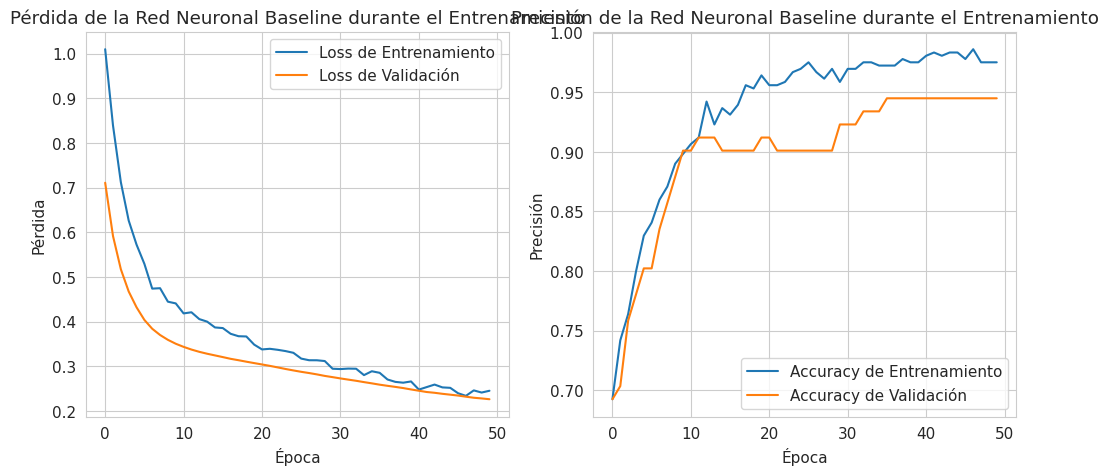


--- Evaluación de la Red Neuronal Baseline ---
BASELINE: {'Accuracy': 0.9561, 'Precision': 0.9512, 'Recall': 0.9286, 'F1': 0.9398, 'AUC': np.float64(0.9974)}

Classification Report (Baseline):
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        72
           1       0.95      0.93      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix (Baseline):


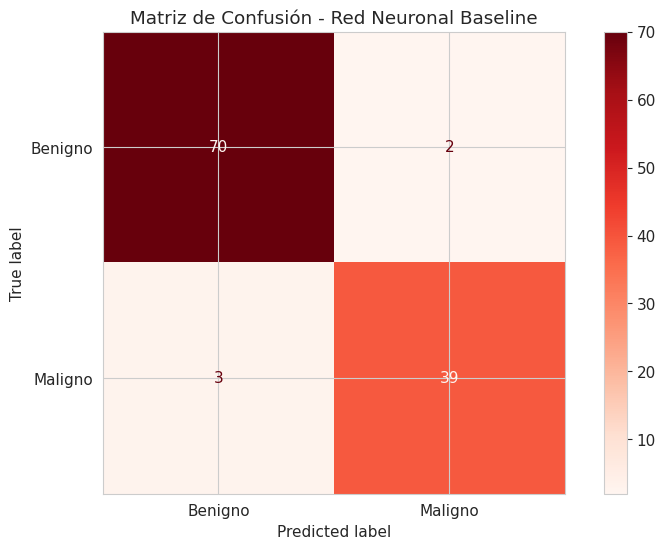

<Figure size 800x600 with 0 Axes>

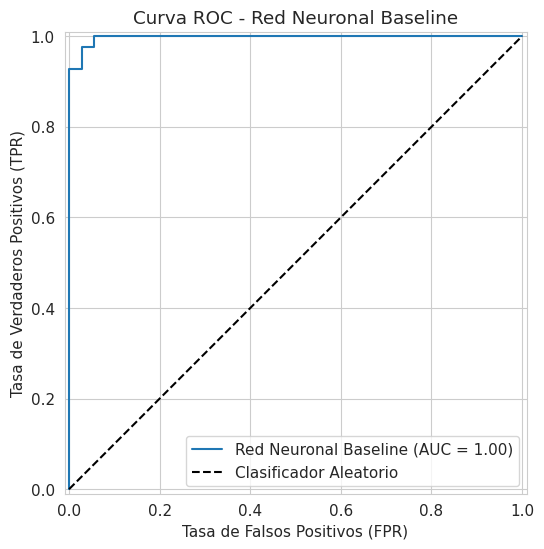

Modelo de Red Neuronal Baseline guardado en 'best_neural_network_model_baseline.keras' (Tamaño: 0.0239 MB)


In [141]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import pandas as pd


# Calcular pesos de clase para manejar el desequilibrio y optimizar el recall
# La clase minoritaria (1: Maligno) tendrá un peso mayor
neg, pos = np.bincount(y_train)
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Pesos de clase calculados: {class_weight}")

# Definir la arquitectura de la red neuronal (baseline) 5 neuronas en la capa oculta,
# función de activación ReLU, y una capa de salida con activación sigmoide
model_nn_base = keras.Sequential([
    layers.Input(shape=(X_train_std.shape[1],)),
    layers.Dense(5, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

# Compilar el modelo con el optimizador Adam, la función de pérdida binaria y la métrica de precisión
model_nn_base.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_nn_base.summary()

# Definir el callback de Early Stopping para detener el entrenamiento si la pérdida de validación no mejora durante 10 épocas consecutivas
early_stopping_base = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entrenamiento del modelo con los datos de entrenamiento estandarizados, usando un 20% de los datos para validación,
# y aplicando los pesos de clase calculados
history_base = model_nn_base.fit(X_train_std, y_train,
                       epochs=50,
                       batch_size=16,
                       validation_split=0.2,
                       verbose=0,
                       class_weight=class_weight,
                       callbacks=[early_stopping_base])

# Visualizar la pérdida y la precisión durante el entrenamiento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_base.history['loss'], label='Loss de Entrenamiento')
plt.plot(history_base.history['val_loss'], label='Loss de Validación')
plt.title('Pérdida de la Red Neuronal Baseline durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_base.history['accuracy'], label='Accuracy de Entrenamiento')
plt.plot(history_base.history['val_accuracy'], label='Accuracy de Validación')
plt.title('Precisión de la Red Neuronal Baseline durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# Evaluar el rendimiento del modelo en el conjunto de prueba using the evaluate function
print("\n--- Evaluación de la Red Neuronal Baseline ---")
row_nn_base, pred_nn_base, proba_nn_base = evaluate(model_nn_base, X_test_std, y_test, "Red Neuronal", "Baseline")
print("BASELINE:", {k: round(v, 4) for k, v in row_nn_base.items() if isinstance(v, float)})

# Reporte de Clasificación
print("\nClassification Report (Baseline):")
print(classification_report(y_test, pred_nn_base))

# Matriz de Confusión
print("\nConfusion Matrix (Baseline):")
cm_nn_base = confusion_matrix(y_test, pred_nn_base)
disp_nn_base = ConfusionMatrixDisplay(confusion_matrix=cm_nn_base, display_labels=['Benigno', 'Maligno'])
disp_nn_base.plot(cmap='Reds')
plt.title('Matriz de Confusión - Red Neuronal Baseline')
plt.show()

# Curva ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, proba_nn_base, name='Red Neuronal Baseline')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.title('Curva ROC - Red Neuronal Baseline')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Guardamos el modelo de red neuronal baseline en disco y registramos su tamaño
model_filename_nn_base = 'best_neural_network_model_baseline.keras'
model_nn_base.save(model_filename_nn_base)
if 'model_sizes' not in locals():
    model_sizes = {}
model_sizes['Red Neuronal_Baseline'] = os.path.getsize(model_filename_nn_base) / (1024 * 1024)
print(f"Modelo de Red Neuronal Baseline guardado en '{model_filename_nn_base}' (Tamaño: {model_sizes['Red Neuronal_Baseline']:.4f} MB)")

## Red neuronal optimizada

Pesos de clase calculados: {0: np.float64(0.7982456140350878), 1: np.float64(1.338235294117647)}


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 11)             │           341 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

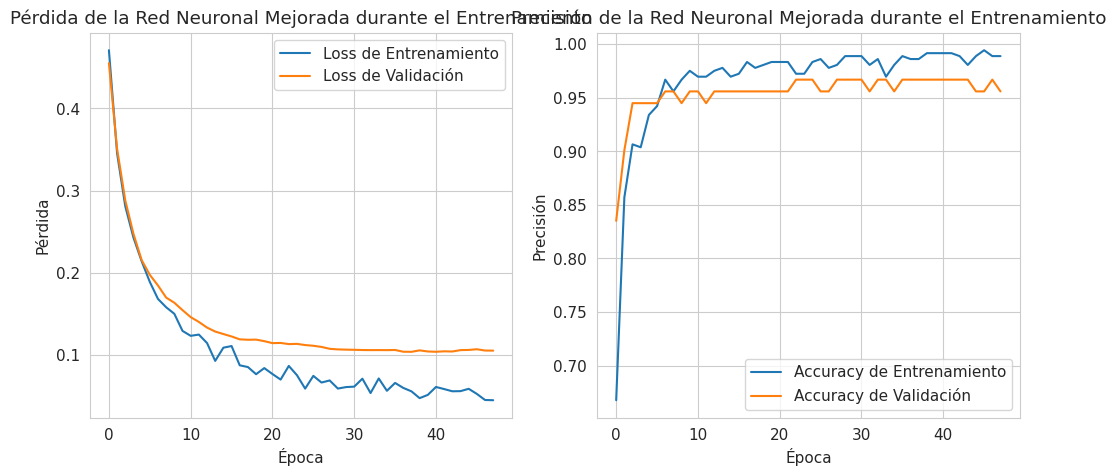

MEJORADO: {'Accuracy': 0.9912, 'Precision': 1.0, 'Recall': 0.9762, 'F1': 0.988, 'AUC': np.float64(0.9967)}

Classification Report (Mejorado):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        72
           1       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114


Confusion Matrix (Mejorado):


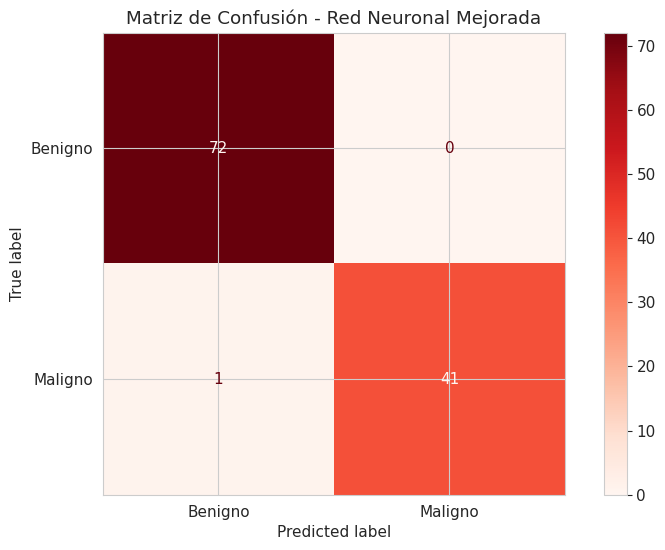

<Figure size 800x600 with 0 Axes>

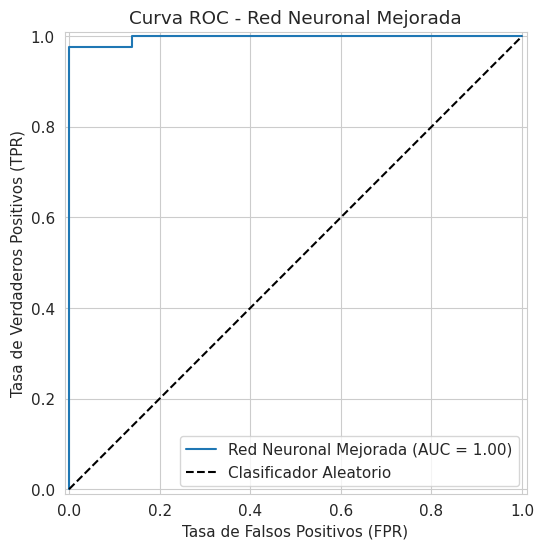

Modelo de Red Neuronal Mejorada guardado en 'best_neural_network_model_mejorado.keras' (Tamaño: 0.0261 MB)


In [142]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import pandas as pd

# Calcular pesos de clase para manejar el desequilibrio y optimizar el recall
# La clase minoritaria (1: Maligno) tendrá un peso mayor
neg, pos = np.bincount(y_train)
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Pesos de clase calculados: {class_weight}")

# Definir la arquitectura de la red neuronal mejorada con 11 neuronas en la capa oculta,
# función de activación ReLU, una capa de Dropout para regularización y una capa de salida con activación sigmoide
model_nn_mejorado = keras.Sequential([
    layers.Input(shape=(X_train_std.shape[1],)),
    layers.Dense(11, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# Compilar el modelo
model_nn_mejorado.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_nn_mejorado.summary()

# Definir el callback de Early Stopping
early_stopping_mejorado = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Entrenar el modelo con los datos de entrenamiento estandarizados, usando un 20% de los datos para validación,
# aplicando los pesos de clase calculados y utilizando el callback de Early Stopping
history_mejorado = model_nn_mejorado.fit(X_train_std, y_train,
                       epochs=50,
                       batch_size=8,
                       validation_split=0.2,
                       verbose=0,
                       class_weight=class_weight,
                       callbacks=[early_stopping_mejorado])

# Visualizar la pérdida y la precisión durante el entrenamiento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mejorado.history['loss'], label='Loss de Entrenamiento')
plt.plot(history_mejorado.history['val_loss'], label='Loss de Validación')
plt.title('Pérdida de la Red Neuronal Mejorada durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mejorado.history['accuracy'], label='Accuracy de Entrenamiento')
plt.plot(history_mejorado.history['val_accuracy'], label='Accuracy de Validación')
plt.title('Precisión de la Red Neuronal Mejorada durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# Use the existing evaluate function
row_nn_mejorado, pred_nn_mejorado, proba_nn_mejorado = evaluate(model_nn_mejorado, X_test_std, y_test, "Red Neuronal", "Mejorado")
print("MEJORADO:", {k: round(v, 4) for k, v in row_nn_mejorado.items() if isinstance(v, float)})
print("\nClassification Report (Mejorado):")
print(classification_report(y_test, pred_nn_mejorado))

# Matriz de Confusión
print("\nConfusion Matrix (Mejorado):")
cm_nn_mejorado = confusion_matrix(y_test, pred_nn_mejorado)
disp_nn_mejorado = ConfusionMatrixDisplay(confusion_matrix=cm_nn_mejorado, display_labels=['Benigno', 'Maligno'])
disp_nn_mejorado.plot(cmap='Reds')
plt.title('Matriz de Confusión - Red Neuronal Mejorada')
plt.show()

# Curva ROC
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, proba_nn_mejorado, name='Red Neuronal Mejorada')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.title('Curva ROC - Red Neuronal Mejorada')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Guardar el modelo en formato Keras (SavedModel) con extensión .keras
model_filename_nn_mejorado = 'best_neural_network_model_mejorado.keras'
model_nn_mejorado.save(model_filename_nn_mejorado)
if 'model_sizes' not in locals():
    model_sizes = {}
model_sizes['Red Neuronal_Mejorado'] = os.path.getsize(model_filename_nn_mejorado) / (1024 * 1024)
print(f"Modelo de Red Neuronal Mejorada guardado en '{model_filename_nn_mejorado}' (Tamaño: {model_sizes['Red Neuronal_Mejorado']:.4f} MB)")

## 24. Tabla Comparativa de Modelos (Versiones Mejoradas)

In [143]:
import pandas as pd
import numpy as np

results_mejorado_df = pd.DataFrame(results)
results_mejorado_df = results_mejorado_df[results_mejorado_df['Versión'] == 'Mejorado'].copy()
results_mejorado_df = results_mejorado_df[['Modelo', 'Versión', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']]

# The neural network metrics are already included in the 'results' list,
# so 'model_metrics' is not needed. We can directly use results_mejorado_df.
comparative_df = results_mejorado_df

# Helper function to get the correct key for model_sizes dictionary
def get_model_size_key(model_name, version):
    if model_name == 'Red Neuronal':
        return f"{model_name}_{version}"
    return model_name

# Agregar la columna de tamaño del modelo en KB
comparative_df['Peso_KB'] = comparative_df.apply(lambda row: model_sizes.get(get_model_size_key(row['Modelo'], row['Versión']), np.nan) * 1024, axis=1) # Convert MB to KB

# Redondear las métricas y el peso para una mejor visualización
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'Peso_KB']:
    if col in comparative_df.columns:
        comparative_df[col] = comparative_df[col].round(4)

# Ordenar por Recall para ver los mejores modelos primero
comparative_df = comparative_df.sort_values(by='Recall', ascending=False).reset_index(drop=True)

display(comparative_df)

,Modelo,Versión,Accuracy,Precision,Recall,F1,AUC,Peso_KB
0,Reg. Logística,Mejorado,0.9825,0.9762,0.9762,0.9762,0.9954,0.9990
1,Red Neuronal,Mejorado,0.9912,1.0000,0.9762,0.9880,0.9967,26.7373
2,SVM,Mejorado,0.9123,0.8333,0.9524,0.8889,0.9745,73.2764
3,KNN,Mejorado,0.9649,1.0000,0.9048,0.9500,0.9861,75.4258
4,Gradient Boosting,Mejorado,0.9649,1.0000,0.9048,0.9500,0.9964,74.1963
5,Random Forest,Mejorado,0.9649,1.0000,0.9048,0.9500,0.9937,318.1494
6,Árbol de Decisión,Mejorado,0.9298,0.9250,0.8810,0.9024,0.9196,4.9463
7,Naive Bayes,Mejorado,0.9386,0.9730,0.8571,0.9114,0.9921,1.3818


## 25. Graficos comparativos de los modelos

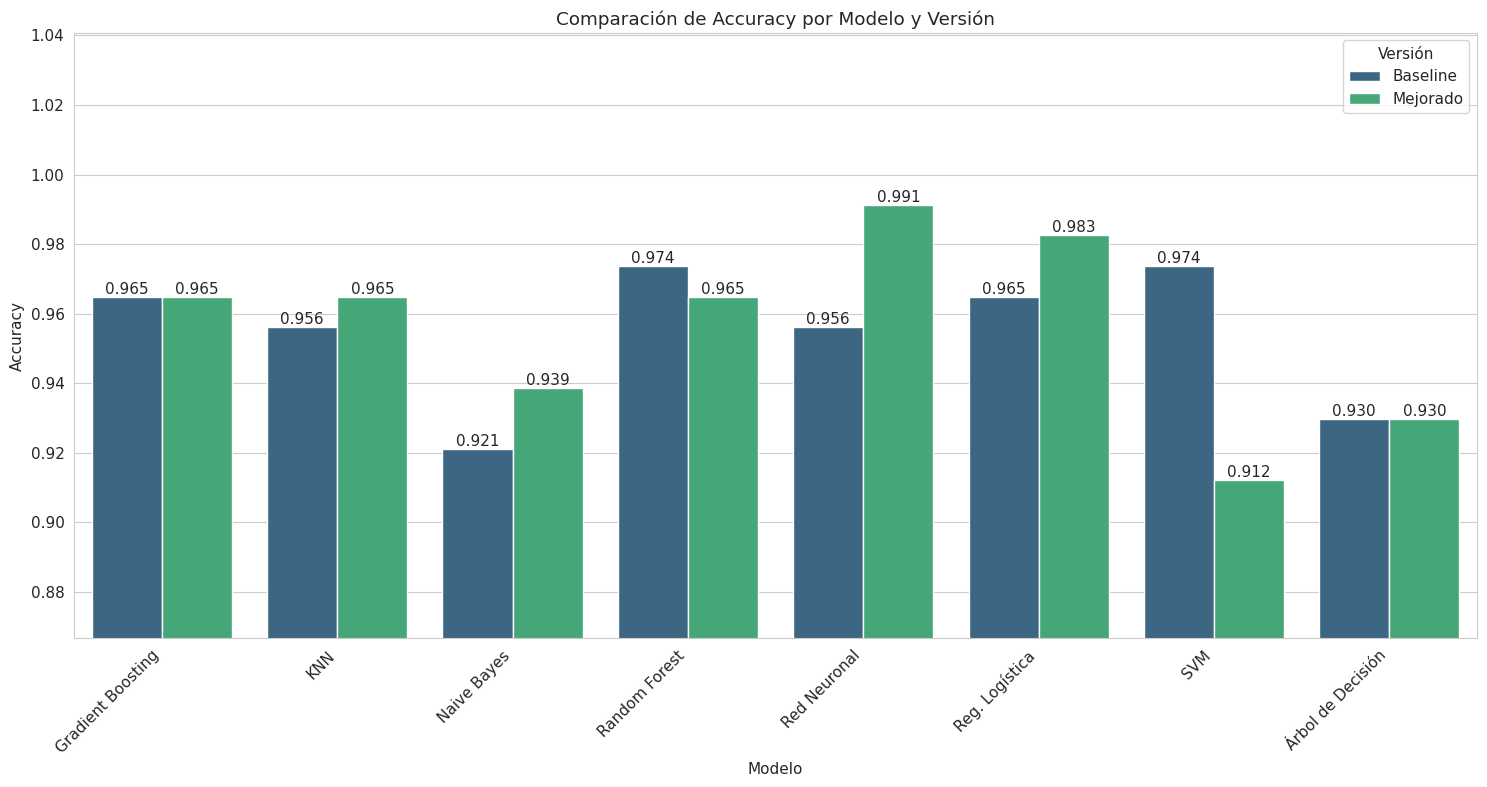

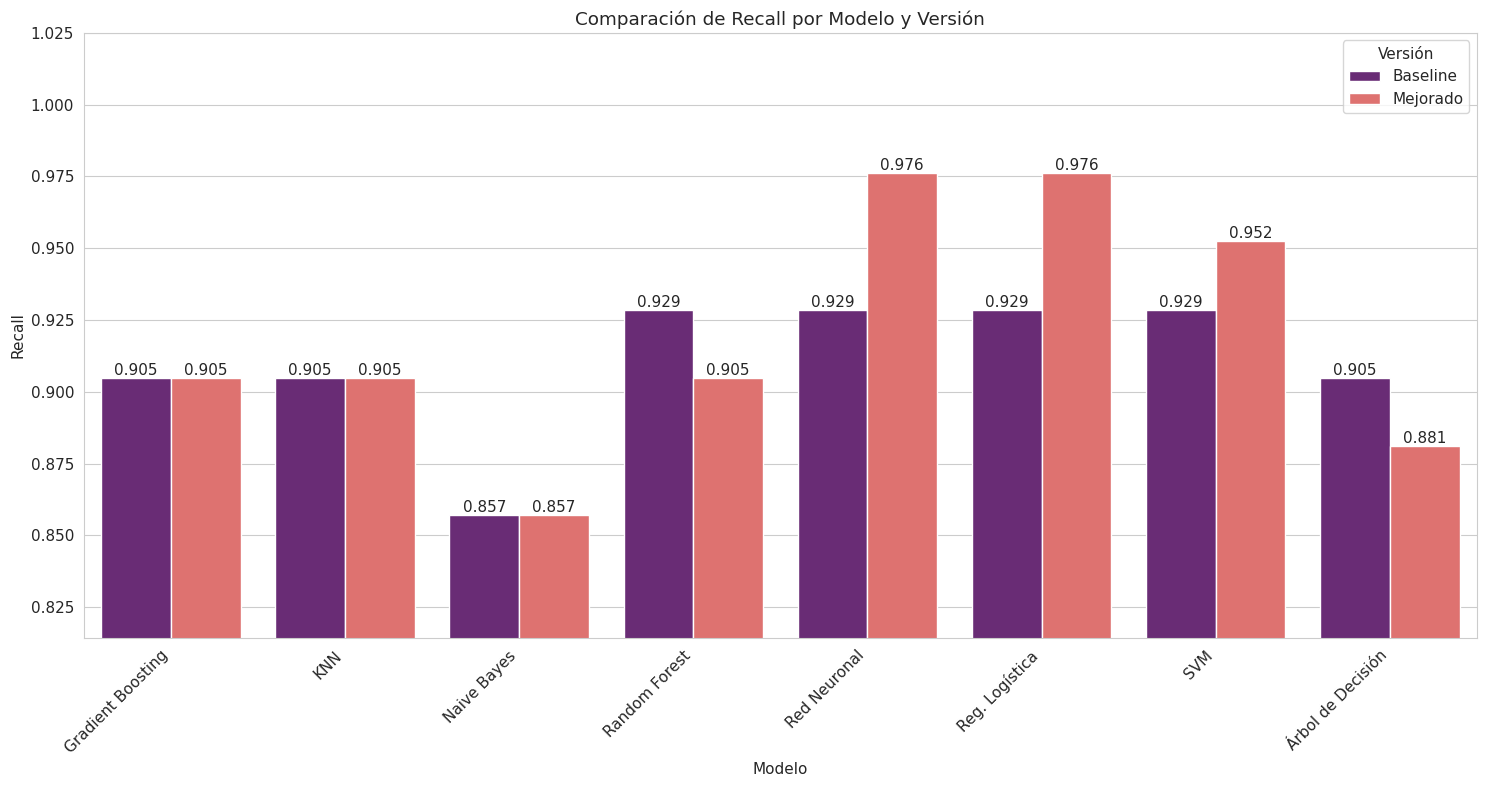

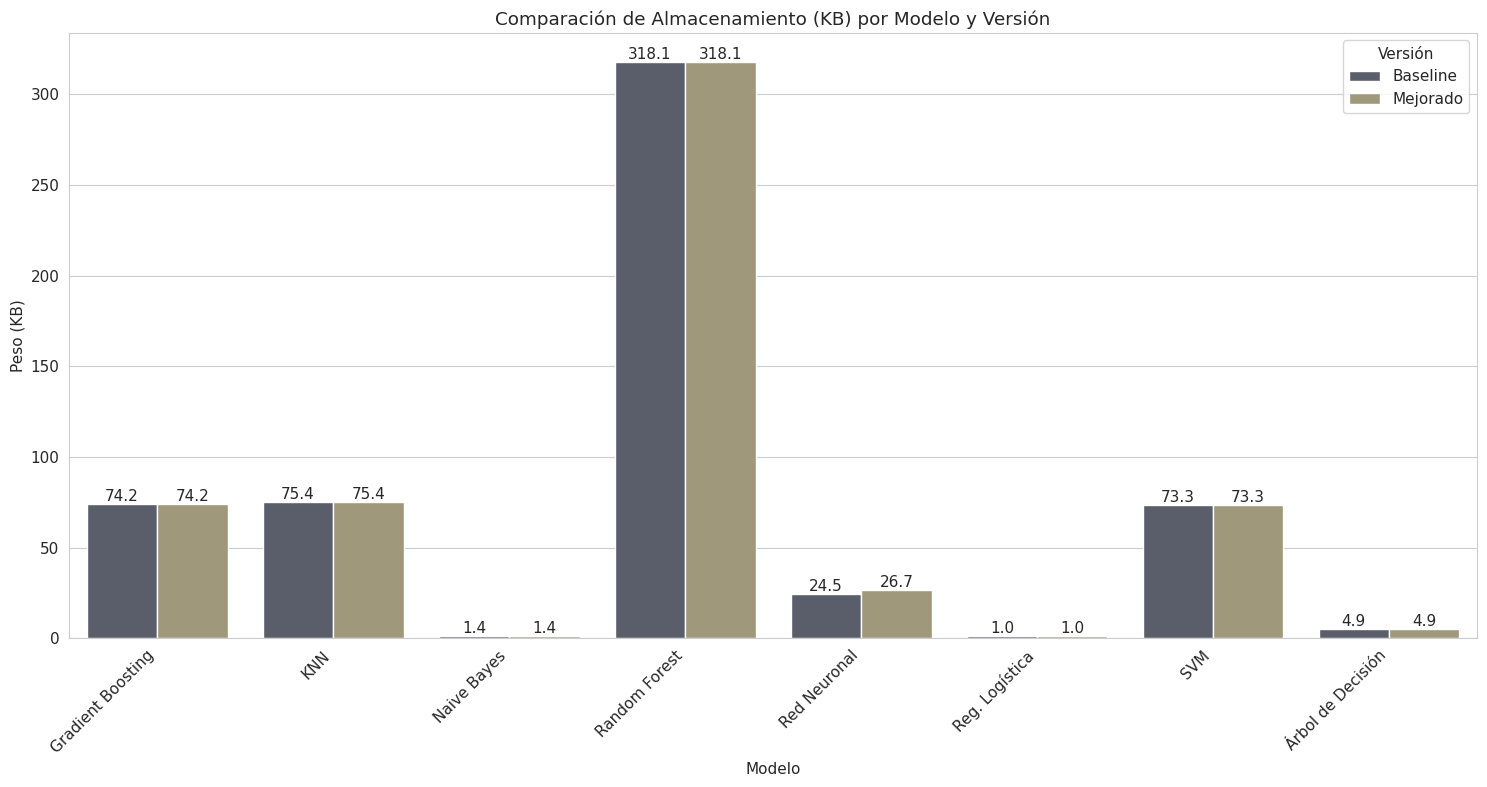

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os # Import os module to get file size

full_comparative_df = pd.DataFrame(results)

if 'Red Neuronal_Baseline' not in model_sizes or model_sizes['Red Neuronal_Baseline'] == 0:
    model_filename_nn_base = 'best_neural_network_model_baseline.keras'
    if os.path.exists(model_filename_nn_base):
        model_sizes['Red Neuronal_Baseline'] = os.path.getsize(model_filename_nn_base) / (1024 * 1024)
    else:
        print(f"Warning: {model_filename_nn_base} not found. Baseline Neural Network size might be incorrect.")

if 'Red Neuronal_Mejorado' not in model_sizes or model_sizes['Red Neuronal_Mejorado'] == 0:
    model_filename_nn_mejorado = 'best_neural_network_model_mejorado.keras'
    if os.path.exists(model_filename_nn_mejorado):
        model_sizes['Red Neuronal_Mejorado'] = os.path.getsize(model_filename_nn_mejorado) / (1024 * 1024)
    else:
        print(f"Warning: {model_filename_nn_mejorado} not found. Mejorado Neural Network size might be incorrect.")

def get_model_size_kb(row):
    model_name = row['Modelo']
    version_name = row['Versión']
    key = model_name
    if model_name == 'Red Neuronal':
        key = f"{model_name}_{version_name}"
    return model_sizes.get(key, np.nan) * 1024

full_comparative_df['Peso_KB'] = full_comparative_df.apply(get_model_size_kb, axis=1)

# Redondear las métricas y el peso para una mejor visualización
for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']:
    if col in full_comparative_df.columns:
        full_comparative_df[col] = full_comparative_df[col].round(4)

if 'Peso_KB' in full_comparative_df.columns:
    full_comparative_df['Peso_KB'] = full_comparative_df['Peso_KB'].round(1)

# Ordenar por Modelo y Versión para una mejor visualización
full_comparative_df = full_comparative_df.sort_values(by=['Modelo', 'Versión']).reset_index(drop=True)

# Establecer el estilo de los gráficos
sns.set_style("whitegrid")

# Gráfico de barras para Accuracy
plt.figure(figsize=(15, 8))
ax_acc = sns.barplot(x='Modelo', y='Accuracy', hue='Versión', data=full_comparative_df, palette='viridis')
plt.title('Comparación de Accuracy por Modelo y Versión')
plt.xlabel('Modelo')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(full_comparative_df['Accuracy'].min() * 0.95, full_comparative_df['Accuracy'].max() * 1.05)
for container in ax_acc.containers:
    ax_acc.bar_label(container, fmt='%.3f')
plt.tight_layout()
plt.show()

# Gráfico de barras para Recall
plt.figure(figsize=(15, 8))
ax_rec = sns.barplot(x='Modelo', y='Recall', hue='Versión', data=full_comparative_df, palette='magma')
plt.title('Comparación de Recall por Modelo y Versión')
plt.xlabel('Modelo')
plt.ylabel('Recall')
plt.xticks(rotation=45, ha='right')
plt.ylim(full_comparative_df['Recall'].min() * 0.95, full_comparative_df['Recall'].max() * 1.05)
for container in ax_rec.containers:
    ax_rec.bar_label(container, fmt='%.3f')
plt.tight_layout()
plt.show()

# Gráfico de barras para Almacenamiento (Peso_KB)
plt.figure(figsize=(15, 8))
ax_peso = sns.barplot(x='Modelo', y='Peso_KB', hue='Versión', data=full_comparative_df, palette='cividis')
plt.title('Comparación de Almacenamiento (KB) por Modelo y Versión')
plt.xlabel('Modelo')
plt.ylabel('Peso (KB)')
plt.xticks(rotation=45, ha='right')

for container in ax_peso.containers:
    ax_peso.bar_label(container, fmt='%.1f')
plt.tight_layout()
plt.show()

## Conclusiones finales

1. El mejor modelo por el recall es la **Red Neuronal Mejorada** y **La regresión Logística Mejorada**.
2. El mejor modelo por Accuracy es el **Red Neuronal Mejorada** y **La regresión Logística Mejorada**.
3. El mejor modelo por AUC es la **Red Neuronal Mejorada**.
4. Considerando las métricas anteriores, el mejor balance lo tiene la **Red Neuronal Mejorada**, si consideramos el almacenamiento, el mejor es la **Regresión Logística**

---
## 🔧 Aplicación Profesional — Learning by Doing

> *Cada integrante del equipo describe en 2-3 líneas cómo aplicaría los contenidos de esta semana en su
> entorno laboral o proyecto de titulación.*

**Jorge Armando Quizamánchuro Fuel:**
En Psico Platform, este flujo de preprocesamiento del Titanic — donde la mayor parte del esfuerzo va en
limpiar, imputar y codificar variables heterogéneas — es análogo al reto que enfrento con datos de
cuestionarios psicológicos: campos de texto libre, escalas Likert, variables faltantes y categorías que
deben codificarse con criterio clínico antes de entrenar cualquier modelo de detección de riesgo.

**Jonathan Fabricio Gualli Ramírez:**
.

**Raúl Marcelo Salazar Gamboa:**

Además de la regresión logística, el uso de modelos avanzados como Gradient Boosting, Random Forest y Redes Neuronales permite desarrollar sistemas de scoring dinámicos para clientes institucionales, incorporando señales no lineales y relaciones complejas entre variables. Estos modelos pueden utilizar información transaccional, patrones de liquidez, estacionalidad de flujos y métricas de concentración para anticipar comportamientos atípicos.


---